In [1]:
"""
File: convert_tng_to_spam.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Apr-11

Description: This script is designed to take IllustrisTNG subhalo data,
    and convert it into a format that can be used by the SPAM simulator. 

References: 
- Sections of this code were written with the assistance of ChatGPT made by OpenAI.
- TNG50 Simulation Data
    - Nelson, D. et al. (2015). The Illustris Simulation: Public Data Release. Astronomy and Computing, 13, 12–37. https://doi.org/10.1016/j.ascom.2015.09.003
    - Nelson, D. et al. (2019). First results from the TNG50 simulation: Galactic outflows driven by supernovae and black hole feedback. Monthly Notices of the Royal Astronomical Society, 490(3), 3234–3261. https://doi.org/10.1093/mnras/stz2306
    - Pillepich, A. et al. (2019). First results from the TNG50 simulation: The evolution of stellar and gaseous discs across cosmic time. Monthly Notices of the Royal Astronomical Society, 490(3), 3196–3233. https://doi.org/10.1093/mnras/stz2338

"""
# ================================ IMPORTS ================================ #
import os, sys, argparse, logging
import math, gzip
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI
from scipy.interpolate import CubicSpline, CubicHermiteSpline, interp1d

# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# Import project modules
import IllustrisTNG.tng_functions as tf
import Optimization_Methods.optimization_manager as om
import Simulator.new_simulator as sim
import utilities.general_utility as gu

# ================================ GLOBALS ================================ #
# Global logger from main program
script_args, LOGGER = gu.initialize_environment()
logger = LOGGER # Because I hate typing all caps

buildEnv = True

# # If buildEnv is True, then we can assume we're in a jupyter notebook
if buildEnv:
    # LOGGER = gu.add_jupyter_stream_handler()
    LOGGER.setLevel(logging.DEBUG)

# Set NumPy print options to reduce the precision to 3 decimal places
np.set_printoptions(precision=2)

LOGGER.debug("Import Done")

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-izww_hhf because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Time:2024-12-13 13:56:10,485 - [1608854189.<module>] - DEBUG - Import Done


In [2]:
# ================================ INPUT ARGUMENTS ================================ #

# Define argument parser function 
def initParser():
    # Define
    parser = argparse.ArgumentParser()

    # Generic Arguments
    parser.add_argument('-i', '--input', type=str, help='Generic Input for misc functions')
    parser.add_argument('-o', '--output', type=str, help='Generic Output for misc functions')

    parser.add_argument('-i2', '--input_2', type=str, help='Generic Input for misc functions')
    parser.add_argument('-i3', '--input_3', type=str, help='Generic Input for misc functions')
    parser.add_argument('-i4', '--input_4', type=str, help='Generic Input for misc functions')

    # Specific Arguments
    parser.add_argument('-id', '--target_id', type=int, help='Target ID')
    parser.add_argument('-ow', '--overwrite', type=bool, default = False, help='Overwrite existing files')
    parser.add_argument('-f', '--function', type=str,  help='Function to run')

    return parser

# A temp parser to do internal development testing
PARSER = initParser()

# CORE FUNCTIONS
The following are the core functions needed to convert from TNG to SPAM.

In [ ]:
# ================================ CONSTANTS ================================ #

# Constants from Java code
G_NEWTON = 6.67430e-11         # Gravitational constant in m^3 kg^-1 s^-2
KG_PER_SOLAR_MASS = 1.98892e30   # Solar mass in kg
METERS_PER_PC = 3.08567758128e16   # Meters per parsec
SECONDS_PER_YEAR = 3.15576e7    # Seconds per year

# THESE ARE PULLED FROM JAVA CODE of SPAM
# Derived units for calculations
MU_kg = 1.0e11 * KG_PER_SOLAR_MASS  # 1e11 solar masses in kg
DU_m = 15.0 * 1000 * METERS_PER_PC  # 15 kpc in meters
TU_s = math.sqrt(DU_m * DU_m * DU_m / (G_NEWTON * MU_kg))  # Time unit in seconds (Based on Kepler's third law...?)

# SPAM standard units
spam_units = {

    # Mass unit - ( 10^11 solar masses )
    "mass_unit_solar_masses": 1e11,  # Mass unit in solar masses
    "mass_unit_kg": 1e11 * KG_PER_SOLAR_MASS,  # Mass unit in kg

    # Distance unit - ( 15 kpc )
    "distance_unit_kpc": 15.0,  # Distance unit in kiloparsecs
    "distance_units_pc": 15.0 * 1000,  # Distance unit in parsecs
    "distance_unit_m": 15.0 * 1000 * METERS_PER_PC ,  # Distance unit in meters

    # Time unit - ( roughly 85 Myr )
    "time_unit_s": None,  # To be calculated below

    # Velocity unit - ( roughly 170 km/s )
    "velocity_unit_m_per_s": None,  # To be calculated below
    "velocity_unit_km_per_s": None,  # To be calculated below

    # Acceleration unit
    "acceleration_unit_m_per_s2": None,  # To be calculated below

}

# Calculate time unit using Kepler's third law
spam_units["time_unit_s"] = math.sqrt(
    spam_units["distance_unit_m"] ** 3 / (G_NEWTON * spam_units["mass_unit_kg"])
)

# Calculate velocity unit (distance unit per time unit)
spam_units["velocity_unit_m_per_s"] = spam_units["distance_unit_m"] / spam_units["time_unit_s"]
spam_units["velocity_unit_km_per_s"] = spam_units["velocity_unit_m_per_s"] / 1000 # 1000 meters per kilometer

# Calculate acceleration unit (velocity unit per time unit)
spam_units["acceleration_unit_m_per_s2"] = spam_units["velocity_unit_m_per_s"] / spam_units["time_unit_s"]

# Dictionary of units for specific fields in the IllustrisTNG data
tng_units = {
    # Mass unit: 1e10 solar masses in grams
    "mass_unit_solar_masses": 1e10,
    "mass_unit_kg": 1e10 * KG_PER_SOLAR_MASS,  # Convert kg to grams

    # Distance unit: 1 kpc in centimeters (comoving kiloparsecs per h)
    "distance_unit_kpc": 1.0,  # 1 kpc
    "distance_unit_pc" : 1e3, # 1 kpc in pc
    "distance_unit_m": 1e3 * METERS_PER_PC, # 1 kpc in meters

    # Velocity unit: 1 km/s in cm/s
    "velocity_unit_km_per_s": 1.0,

    # Time unit: 1 Gyr in seconds
    "time_unit_Gyr": 1.0,
    "time_unit_s": 1e9 * SECONDS_PER_YEAR,  # Convert Gyr to seconds
}

# Print comparing JAVA to Fortran units
if buildEnv:
    print("Mass Comparison: ")
    print("\t - Fortran (kg):", spam_units['mass_unit_kg'])
    print("\t - JAVA (kg):", MU_kg ) 

    print("Distance Comparison: ")
    print("\t - Fortran (m):", spam_units['distance_unit_m'])
    print("\t - JAVA (m):", DU_m )

    print("Time Comparison: ")
    print("\t - Fortran (s): %e" % spam_units['time_unit_s'])
    print("\t - JAVA (s): %e" % TU_s )

    print("\nValues are the same but in different units. \n")


#   Standardized parameter array for SPAM model:
'''
    [0]: X-coordinate of the secondary galaxy's position
    [1]: Y-coordinate of the secondary galaxy's position
    [2]: Z-coordinate of the secondary galaxy's position
    [3]: X-component of the secondary galaxy's velocity
    [4]: Y-component of the secondary galaxy's velocity
    [5]: Z-component of the secondary galaxy's velocity
    [6]: Mass of the primary galaxy
    [7]: Mass of the secondary galaxy
    [8]: Outer radius of the primary galaxy
    [9]: Outer radius of the secondary galaxy
    [10]: Azimuthal angle for the primary galaxy
    [11]: Azimuthal angle for the secondary galaxy
    [12]: Inclination angle for the primary galaxy
    [13]: Inclination angle for the secondary galaxy
    [14]: Softening length for the primary galaxy
    [15]: Softening length for the secondary galaxy
    [16-19]: Particle distribution of the primary galaxy. (Unused)
    [19-21]: Particle distribution of the secondary galaxy. (Unused)
'''

# Create diction naming the parameters
spam_param_note = {
    0: 'X-coordinate of the secondary galaxy\'s position',
    1: 'Y-coordinate of the secondary galaxy\'s position',
    2: 'Z-coordinate of the secondary galaxy\'s position',
    3: 'X-component of the secondary galaxy\'s velocity',
    4: 'Y-component of the secondary galaxy\'s velocity',
    5: 'Z-component of the secondary galaxy\'s velocity',
    6: 'Mass of the primary galaxy',
    7: 'Mass of the secondary galaxy',
    8: 'Outer radius of the primary galaxy',
    9: 'Outer radius of the secondary galaxy',
    10: 'Azimuthal angle for the primary galaxy',
    11: 'Azimuthal angle for the secondary galaxy',
    12: 'Inclination angle for the primary galaxy',
    13: 'Inclination angle for the secondary galaxy',
    14: 'Softening length for the primary galaxy',
    15: 'Softening length for the secondary galaxy',
    16: 'Particle distribution of the primary galaxy',
    17: 'Particle distribution of the primary galaxy',
    18: 'Particle distribution of the primary galaxy',
    19: 'Particle distribution of the primary galaxy',
    20: 'Particle distribution of the secondary galaxy',
    21: 'Particle distribution of the secondary galaxy',
    22: 'Particle distribution of the secondary galaxy',
    23: 'Particle distribution of the secondary galaxy',
}


Mass Comparison: 
	 - Fortran (kg): 1.98892e+41
	 - JAVA (kg): 1.98892e+41
Distance Comparison: 
	 - Fortran (m): 4.62851637192e+20
	 - JAVA (m): 4.62851637192e+20
Time Comparison: 
	 - Fortran (s): 2.733073e+15
	 - JAVA (s): 2.733073e+15

Values are the same but in different units. 



In [4]:
def convert_numpy_arrays( df ):
    """
    Convert strings of arrays into numpy arrays in a pandas DataFrame.
    """

    # Function to convert a string representation of a numpy array back to a numpy array
    def convert_to_numpy_array(array_str):
        # Remove the brackets and split the string by whitespace
        array_str = array_str.strip('[]')
        # Convert to a numpy array of integers (or float if needed)
        return np.array(array_str.split(), dtype=float)
    
    # Iterate over each column and convert strings to numpy arrays if necessary
    for column in df.columns:
        # Check if the column contains array-like strings
        if df[column].dtype == object and df[column].str.startswith('[').all():
            df[column] = df[column].apply(convert_to_numpy_array)

    return df

if buildEnv and True:
    
    # Specify the file path to illustrisTNG Target info
    file_path = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl'

    # Read the CSV file into a Pandas DataFrame
    tng_targets = pd.read_pickle(file_path, )
    print(f"All Targets: {len(tng_targets)}")

    # write note in a single string
    note = """
    #####   Special note of pre-fixes in file   #####
    1st character 'p' vs 's' indicates 'primary' vs 'secondary' galaxy.
    If 2nd character is absent, data is from illustrisTNG Subhalo Catalog Data.
    If 2nd character is present, data is dynamically calculated after doing historical particle re-attribution.
    2nd characters 'a' and 's' stand for 'all particles' and 'star particles' respectively.
    """
    print(note)
    
    print( tng_targets.columns )
    # for i, k in enumerate(tng_targets.columns):
    #     print(i, k)


All Targets: 1268

    #####   Special note of pre-fixes in file   #####
    1st character 'p' vs 's' indicates 'primary' vs 'secondary' galaxy.
    If 2nd character is absent, data is from illustrisTNG Subhalo Catalog Data.
    If 2nd character is present, data is dynamically calculated after doing historical particle re-attribution.
    2nd characters 'a' and 's' stand for 'all particles' and 'star particles' respectively.
    
Index(['moi_2', 'snap', 'merger_snap', 'p_moi_1', 's_moi_1', 'xy_projection',
       'p_face_projection', 's_face_projection', 'p_SubhaloID', 's_SubhaloID',
       ...
       'sa_SubhaloPos_orbital_frame', 'sa_SubhaloCM_orbital_frame',
       'sa_SubhaloVel_orbital_frame', 'sa_SubhaloSpin_orbital_frame',
       'ss_SubhaloPos_orbital_frame', 'ss_SubhaloCM_orbital_frame',
       'ss_SubhaloVel_orbital_frame', 'ss_SubhaloSpin_orbital_frame',
       'img_name_1', 'moi_4_rating'],
      dtype='object', length=111)


In [5]:
# Let's focus on a single target for development purposes
if buildEnv:

    # Convert entire column of moi_1, moi_2, p_SubhaloIDRaw, s_SubhaloIDRaw to int64
    # tng_targets['moi_1'] = tng_targets['moi_1'].astype('int64')
    tng_targets['moi_2'] = tng_targets['moi_2'].astype('int64')
    tng_targets['p_SubhaloIDRaw'] = tng_targets['p_SubhaloIDRaw'].astype('int64')
    tng_targets['s_SubhaloIDRaw'] = tng_targets['s_SubhaloIDRaw'].astype('int64')

    # Unique ID for primary galaxy
    pid = 62000000190717

    # Get row with this p_SubhaloIDRaw
    t_row = tng_targets.loc[ tng_targets['p_SubhaloIDRaw'] == pid ].iloc[0]

    # Get moi_2 id and grab all rows with this value
    m2_id = t_row['moi_2']
    print( f'MOI_2: {m2_id}' )
    t_df = tng_targets.loc[ tng_targets['moi_2'] == m2_id ]
    print(f'Target DF: {len(t_df)}\n')

    print(f'Target Row:\n{t_row}')

MOI_2: 67000000184181
Target DF: 26

Target Row:
moi_2                                                              67000000184181
snap                                                                           62
merger_snap                                                                  65.0
p_moi_1                                                          50000000220008.0
s_moi_1                                                          50000000220010.0
                                                      ...                        
ss_SubhaloCM_orbital_frame      [16.59689896769487, 0.6179258303454844, 0.0204...
ss_SubhaloVel_orbital_frame     [8.724396910270222, -58.22408825900726, -12.10...
ss_SubhaloSpin_orbital_frame    [-703.8460704236377, 612.369167093556, -5810.4...
img_name_1                                              Target_62000000190717.png
moi_4_rating                                                                    5
Name: 1010, Length: 111, dtype: object


In [6]:
# ================================ FUNCTIONS ================================ #
def calculate_orientation_angles( spin ):
    """
    Calculate the azimuthal and inclination angles from the spin components.

    Parameters:
    spin (float array): [ x, y, z ] components of the spin.

    Returns:
    tuple: (phi, theta) where phi is the azimuthal angle and theta is the inclination angle,
            both in radians.
    """
    x, y, z = spin
    # Calculate the magnitude of the vector
    r = np.sqrt(x**2 + y**2 + z**2)

    # Calculate the azimuthal angle in radians
    phi = np.arctan2(y, x)  # This returns the angle in the range [-pi, pi]

    # Calculate the inclination angle in radians
    if r == 0:
        theta = 0  # Undefined direction for a zero vector, set arbitrarily to 0
    else:
        theta = np.arccos(z / r)

    return np.degrees(phi), np.degrees(theta)


In [7]:
def standardize_tng_parameters_v1( subhalo_kinematics, radius_scale=2.5 ):
    """
    Construct the standardized parameter array for kinematic data from the IllustrisTNG subhalo catalog.
    Uses a mix of the catalog data, and calculated dynamics of all particles or star particles. 

    Args:
        subhalo_kinematics (pd.Series): The dynamic kinematic data calculated elsewhere.

    Returns:
        param_array (np.array): A standardized parameter array based on the SPAM simulator.
    """

    LOGGER.debug("Standardizing TNG parameters...")

    # Initialize the parameter array
    tng_ar = np.zeros(22)

    # position and velocity. 
    # Primary is always at origin, secondary is in reference to primary's location
    for i in range(3):
        # tng_ar[i] = subhalo_kinematics['ss_SubhaloCM'][i] - subhalo_kinematics['ps_SubhaloCM'][i]  # position
        tng_ar[i] = subhalo_kinematics['s_SubhaloPos_orbital_frame'][i] - subhalo_kinematics['p_SubhaloPos_orbital_frame'][i]  # position
        tng_ar[i+3] = subhalo_kinematics['ss_SubhaloVel_orbital_frame'][i] - subhalo_kinematics['ps_SubhaloVel_orbital_frame'][i]  # velocity

    # masses, using total mass
    tng_ar[6] = subhalo_kinematics['pa_SubhaloMass']
    tng_ar[7] = subhalo_kinematics['sa_SubhaloMass']
    
    # Radii, using stars to disk radii
    # Use scale of half mass radius
    tng_ar[8] = radius_scale * subhalo_kinematics['ps_SubhaloHalfmassRad']
    tng_ar[9] = radius_scale * subhalo_kinematics['ss_SubhaloHalfmassRad']

    # orientation angles, using stars to orient disk
    tng_ar[10], tng_ar[12] = calculate_orientation_angles( subhalo_kinematics['ps_SubhaloSpin_orbital_frame'] )
    tng_ar[11], tng_ar[13] = calculate_orientation_angles( subhalo_kinematics['ss_SubhaloSpin_orbital_frame'] )

    # Just use a scale of previously radius value
    s = 0.1
    tng_ar[14] = s * tng_ar[8]
    tng_ar[15] = s * tng_ar[9]

    # Use 0 for bulge, disk, and halo.  
    # # SPAM might be able to estimate these values....? 
    tng_ar[16:22] = np.zeros(6)    

    return tng_ar

if buildEnv:
    # test_target = tng_targets.iloc[0]
    #print( test_target )
    test_tng_ar = standardize_tng_parameters_v1( t_row )
    print( test_tng_ar )


Time:2024-12-13 13:56:11,377 - [1019555727.standardize_tng_parameters_v1] - DEBUG - Standardizing TNG parameters...


[ 3.88e+01 -2.37e+00  3.85e-07  1.52e+01 -1.02e+02 -2.11e+01  1.20e+02
  1.10e+01  1.28e+01  1.35e+01  7.89e+01  1.39e+02  1.60e+02  1.71e+02
  1.28e+00  1.35e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00]


In [ ]:
def standardize_tng_parameters_v2( subhalo_df, current_snap, past_snap, radius_scale=2.5 ):
    """
    Construct the standardized parameter array for kinematic data from the IllustrisTNG subhalo catalog.
    Uses a mix of the catalog data, and calculated dynamics of all particles or star particles. 

    Args:
        subhalo_df (pd.DataFrame): The dynamic kinematic data calculated over time
        snap (int): The snapshot number to use for the data

    Returns:
        param_array (np.array): A standardized parameter array based on the SPAM simulator.
    """

    LOGGER.debug("Standardizing TNG parameters v2...")

    # Initialize the parameter array
    tng_ar = np.zeros(22)

    # Get current row
    current_kinematics = subhalo_df[ subhalo_df['snap'] == current_snap ].iloc[0]  

    # Get row for past_n snapshots
    past_kinematics = subhalo_df[ subhalo_df['snap'] == past_snap ].iloc[0]

    # position and velocity. 
    # Primary is always at origin, secondary is in reference to primary's location
    for i in range(3):
        # tng_ar[i] = subhalo_kinematics['ss_SubhaloCM'][i] - subhalo_kinematics['ps_SubhaloCM'][i]  # position
        tng_ar[i] = current_kinematics['s_SubhaloPos_orbital_frame'][i] - current_kinematics['p_SubhaloPos_orbital_frame'][i]  # position
        tng_ar[i+3] = current_kinematics['ss_SubhaloVel_orbital_frame'][i] - current_kinematics['ps_SubhaloVel_orbital_frame'][i]  # velocity

    # masses, use past masses in case they've changed in the past_n snapshots
    tng_ar[6] = past_kinematics['pa_SubhaloMass']
    tng_ar[7] = past_kinematics['sa_SubhaloMass']
    
    # Radii, using stars to disk radii
    # Use scale of half mass radius
    tng_ar[8] = radius_scale * past_kinematics['ps_SubhaloHalfmassRad']
    tng_ar[9] = radius_scale * past_kinematics['ss_SubhaloHalfmassRad']

    # orientation angles, using stars to orient disk
    tng_ar[10], tng_ar[12] = calculate_orientation_angles( tf.apply_transformation( current_kinematics['orbital_frame_vel_transform'], np.reshape( past_kinematics['ps_SubhaloSpin'], (1,-1) ),  )[0] )
    tng_ar[11], tng_ar[13] = calculate_orientation_angles( tf.apply_transformation( current_kinematics['orbital_frame_vel_transform'], np.reshape( past_kinematics['ss_SubhaloSpin'], (1,-1) ),  )[0] )

    # Just use a scale of previously radius value. (For inner radius of stars...?)
    s = 0.1
    tng_ar[14] = s * tng_ar[8]
    tng_ar[15] = s * tng_ar[9]

    # Use 0 for bulge, disk, and halo.  
    # # SPAM might be able to estimate these values....? (TODO: VERIFY THIS)
    tng_ar[16:22] = np.zeros(6)    

    return tng_ar

if buildEnv:
    # test_target = tng_targets.iloc[0]
    #print( test_target )

    # Print all columns in t_row with 'orbital_frame' in name
    print( [c for c in t_row.index if 'orbital_frame' in c] )
    

    test_tng_ar_2 = standardize_tng_parameters_v2( t_df, t_row['snap'], t_row['snap'] - 2 )
    
    for i in range( len( test_tng_ar_2 ) ):
        p_diff = 100 * ( test_tng_ar_2[i] - test_tng_ar[i] ) / test_tng_ar[i]
        # print in pretty format
        print( f"{i}: {test_tng_ar_2[i]:.2f} vs {test_tng_ar[i]:.2f} ({p_diff:.2f}%) - {param_dict[i]}" )
    
    # 


In [9]:
def convert_distance_tng_to_spam(tng_dist_ckpch, h=0.7):
    """
    Convert distances from TNG units (ckpc/h) to SPAM distance units.

    Parameters:
    - tng_dist_ckpch: Distance in comoving kiloparsecs per h (ckpc/h).
    - h: Hubble parameter.

    Returns:
    - spam_dist: Distance in SPAM units.
    """

    # Convert ckpc/h to ckpc (comoving kpc)
    dist_kpc = tng_dist_ckpch * h
    # Since we're working with "small scale" structures, use comoving distances as physical distances.

    # Convert ckpc to SPAM distance units (1 SPAM unit = 15 kpc)
    spam_dist = dist_kpc / spam_units["distance_unit_kpc"]
    return spam_dist
# End of convert_distance_tng_to_spam

def convert_velocity_tng_to_spam(tng_vel_kms):
    """
    Convert velocities from TNG units (km/s) to SPAM velocity units.

    Parameters:
    - tng_vel_kms: Velocity in km/s.

    Returns:
    - spam_vel: Velocity in SPAM units.
    """
    # Convert km/s to SPAM velocity units
    spam_vel = tng_vel_kms / spam_units["velocity_unit_km_per_s"]
    return spam_vel
# End of convert_velocity_tng_to_spam

def convert_mass_tng_to_spam(tng_mass_1e10Msunh, h=0.7):
    """
    Convert masses from TNG units (1e10 M⊙/h) to SPAM mass units.

    Parameters:
    - tng_mass_1e10Msunh: Mass in units of 1e10 solar masses per h.
    - h: Hubble parameter.

    Returns:
    - spam_mass: Mass in SPAM units.
    """

    # Convert from 1e10 M⊙/h to M⊙
    mass_Msun = tng_mass_1e10Msunh * 1e10 * h

    # Convert M⊙ to SPAM mass units (1 SPAM unit = 1e11 M⊙)
    spam_mass = mass_Msun / spam_units["mass_unit_solar_masses"]
    return spam_mass
# End of convert_mass_tng_to_spam

def convert_time_tng_to_spam(tng_time_Gyr):
    """
    Convert time from TNG units (Gyr) to SPAM time units.

    Parameters:
    - tng_time_Gyr: Time in Gigayears (Gyr).

    Returns:
    - spam_time: Time in SPAM units.
    """
    # Convert Gyr to seconds
    time_s = tng_time_Gyr * tng_units['time_unit_s']
    # Convert seconds to SPAM time units
    spam_time = time_s / spam_units["time_unit_s"]
    return spam_time
#   End of convert_time_tng_to_spam

def convert_units_tng_to_spam(tng_ar, h=0.7):
    """
    Convert IllustrisTNG data to SPAM units.

    Parameters:
    - tng_ar: numpy array, array of targets in IllustrisTNG units.
        Expected indices:
        [0-2]: Positions (ckpc/h)
        [3-5]: Velocities (km/s)
        [6-7]: Masses (1e10 M⊙/h)
        [8-9]: Radii (ckpc/h)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (ckpc/h)
    - h: float, the Hubble parameter used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - spam_data: numpy array, target converted to SPAM units.
    """
    LOGGER.debug("Converting TNG units to SPAM units...")
    # Initialize spam data array
    spam_data = np.zeros(22)

    # Convert Positions (indices 0-2)
    spam_data[0:3] = convert_distance_tng_to_spam(tng_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    spam_data[3:6] = convert_velocity_tng_to_spam(tng_ar[3:6])

    # Convert Masses (indices 6-7)
    spam_data[6:8] = convert_mass_tng_to_spam(tng_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    spam_data[8:10] = convert_distance_tng_to_spam(tng_ar[8:10], h)
    spam_data[14:16] = convert_distance_tng_to_spam(tng_ar[14:16], h)

    # Use same orientation angles (indices 10-13)
    spam_data[10:14] = tng_ar[10:14]

    # Remaining indices (16-21) are unused or set to zero
    spam_data[16:] = 0.0

    return spam_data
# End of convert_units_tng_to_spam

# Example usage
if buildEnv:
    test_spam_ar = convert_units_tng_to_spam(test_tng_ar)
    for i in range( len( test_spam_ar ) ):
        # print( i, '\t', test_spam_ar[i], '\t', test_tng_ar[i] )
        # Print in a more readable format
        print(f"{i:2d}: {test_spam_ar[i]:.2e}\t{test_tng_ar[i]:.2e}")


Time:2024-12-13 13:56:11,500 - [1776246332.convert_units_tng_to_spam] - DEBUG - Converting TNG units to SPAM units...


 0: 1.81e+00	3.88e+01
 1: -1.10e-01	-2.37e+00
 2: 1.80e-08	3.85e-07
 3: 8.99e-02	1.52e+01
 4: -6.00e-01	-1.02e+02
 5: -1.25e-01	-2.11e+01
 6: 8.37e+00	1.20e+02
 7: 7.73e-01	1.10e+01
 8: 5.96e-01	1.28e+01
 9: 6.29e-01	1.35e+01
10: 7.89e+01	7.89e+01
11: 1.39e+02	1.39e+02
12: 1.60e+02	1.60e+02
13: 1.71e+02	1.71e+02
14: 5.96e-02	1.28e+00
15: 6.29e-02	1.35e+00
16: 0.00e+00	0.00e+00
17: 0.00e+00	0.00e+00
18: 0.00e+00	0.00e+00
19: 0.00e+00	0.00e+00
20: 0.00e+00	0.00e+00
21: 0.00e+00	0.00e+00


In [10]:
def convert_distance_spam_to_tng(spam_dist, h=0.7):
    """
    Convert distances from SPAM units back to TNG units (ckpc/h).

    Parameters:
    - spam_dist: Distance in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_dist_ckpch: Distance in ckpc/h.
    """
    # Convert SPAM units to ckpc
    dist_ckpc = spam_dist * spam_units["distance_unit_kpc"]
    # Convert ckpc to ckpc/h
    tng_dist_ckpch = dist_ckpc / h
    return tng_dist_ckpch
# end of convert_distance_spam_to_tng

def convert_velocity_spam_to_tng(spam_vel):
    """
    Convert velocities from SPAM units back to TNG units (km/s).

    Parameters:
    - spam_vel: Velocity in SPAM units.

    Returns:
    - tng_vel_kms: Velocity in km/s.
    """
    # Convert SPAM velocity units to km/s
    tng_vel_kms = spam_vel * spam_units["velocity_unit_km_per_s"]
    return tng_vel_kms
# end of convert_velocity_spam_to_tng

def convert_mass_spam_to_tng(spam_mass, h=0.7):
    """
    Convert masses from SPAM units back to TNG units (1e10 M⊙/h).

    Parameters:
    - spam_mass: Mass in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_mass_1e10Msunh: Mass in units of 1e10 M⊙/h.
    """
    # Convert SPAM mass units to solar masses
    mass_Msun = spam_mass * spam_units["mass_unit_solar_masses"]
    # Convert solar masses to 1e10 M⊙/h units
    tng_mass_1e10Msunh = (mass_Msun / (1e10 * h))
    return tng_mass_1e10Msunh
# end of convert_mass_spam_to_tng

def convert_time_spam_to_tng(spam_time):
    """
    Convert time from SPAM units back to TNG units (Gyr).

    Parameters:
    - spam_time: Time in SPAM units.

    Returns:
    - tng_time_Gyr: Time in Gigayears (Gyr).
    """
    # Convert SPAM time units to seconds
    time_s = spam_time * spam_units["time_unit_s"]
    # Convert seconds to Gyr
    tng_time_Gyr = time_s / tng_units['time_unit_s']
    return tng_time_Gyr
# end of convert_time_spam_to_tng

def convert_units_spam_to_tng(spam_ar, h=0.7):
    """
    Convert SPAM data back to IllustrisTNG units.

    Parameters:
    - spam_ar: numpy array, array of data in SPAM units.
        Expected indices:
        [0-2]: Positions (SPAM units)
        [3-5]: Velocities (SPAM units)
        [6-7]: Masses (SPAM units)
        [8-9]: Radii (SPAM units)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (SPAM units)
        [16-21]: Additional parameters (unused or zeros)
    - h: float, the Hubble constant used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - tng_data: numpy array, data converted back to TNG units.
    """
    LOGGER.debug("Converting SPAM units to TNG units...")   
    # Initialize tng data array
    tng_data = np.zeros_like(spam_ar)

    # Convert Positions (indices 0-2)
    tng_data[0:3] = convert_distance_spam_to_tng(spam_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    tng_data[3:6] = convert_velocity_spam_to_tng(spam_ar[3:6])

    # Convert Masses (indices 6-7)
    tng_data[6:8] = convert_mass_spam_to_tng(spam_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    tng_data[8:10] = convert_distance_spam_to_tng(spam_ar[8:10], h)
    tng_data[14:16] = convert_distance_spam_to_tng(spam_ar[14:16], h)

    # Copy Orientation Angles (indices 10-13)
    tng_data[10:14] = spam_ar[10:14]

    # Remaining indices (16-21) are unused or zeros
    tng_data[16:] = spam_ar[16:]

    return tng_data
# end of convert_units_spam_to_tng

# Example usage
if buildEnv:
    test_tng_ar_back = convert_units_spam_to_tng(test_spam_ar)

    error_sum = np.sum( np.abs( test_tng_ar - test_tng_ar_back ) )
    print( f"Error Sum: {error_sum}" )

    for i in range( len( test_tng_ar_back ) ):
        # print( test_tng_ar[i], test_tng_ar_back[i] )
        # Print in a more readable format
        print(f"{i:2d}: {test_tng_ar[i]:.2e}\t{test_tng_ar_back[i]:.2e}")


Time:2024-12-13 13:56:11,570 - [1223271590.convert_units_spam_to_tng] - DEBUG - Converting SPAM units to TNG units...


Error Sum: 1.7763568394002505e-14
 0: 3.88e+01	3.88e+01
 1: -2.37e+00	-2.37e+00
 2: 3.85e-07	3.85e-07
 3: 1.52e+01	1.52e+01
 4: -1.02e+02	-1.02e+02
 5: -2.11e+01	-2.11e+01
 6: 1.20e+02	1.20e+02
 7: 1.10e+01	1.10e+01
 8: 1.28e+01	1.28e+01
 9: 1.35e+01	1.35e+01
10: 7.89e+01	7.89e+01
11: 1.39e+02	1.39e+02
12: 1.60e+02	1.60e+02
13: 1.71e+02	1.71e+02
14: 1.28e+00	1.28e+00
15: 1.35e+00	1.35e+00
16: 0.00e+00	0.00e+00
17: 0.00e+00	0.00e+00
18: 0.00e+00	0.00e+00
19: 0.00e+00	0.00e+00
20: 0.00e+00	0.00e+00
21: 0.00e+00	0.00e+00


----
# TESTING TNG TO SPAM CONVERSION

We theorize SPAM can accurately simulate the path and tidal features of colliding galaxies.  To test this, let's see if we can take the TNG dynamics data, run it through SPAM, and recreate the TNG orbital and tidal features of their particles.  

In [11]:
import os
import numpy as np

def extractTargetData(pid, tng_targets, dev_print=False):

    LOGGER.debug("Extracting target data...")
    
    # Unique ID for primary galaxy
    # pid = 62000000190717

    # Get row with this p_SubhaloIDRaw
    t_row = tng_targets.loc[tng_targets['p_SubhaloIDRaw'] == pid]

    # Verify there's only one
    if len(t_row) != 1:
        raise ValueError(f"Error: Didn't find unique row for pid: {pid} - {len(t_row)}")

    # Get the row
    t_row = t_row.iloc[0]

    # Get moi_2 id and grab all rows with this value
    m2_id = t_row['moi_2']
    t_df = tng_targets.loc[tng_targets['moi_2'] == m2_id].copy()

    # Change type of columns
    t_df['moi_2'] = t_df['moi_2'].astype('int64')
    t_df['p_SubhaloIDRaw'] = t_df['p_SubhaloIDRaw'].astype('int64')
    t_df['s_SubhaloIDRaw'] = t_df['s_SubhaloIDRaw'].astype('int64')

    # Add additional columns
    t_df.loc[:, 'times_su'] = convert_time_tng_to_spam(t_df['time_gyr'])
    t_df.sort_values('snap', inplace=True)  # Ensure df is sorted by snap
    t_df.reset_index(drop=True, inplace=True)  # Reset index

    # Pull row with updated info
    t_row = t_df.loc[t_df['p_SubhaloIDRaw'] == pid].iloc[0]

    # Save index this row is at
    t_row['idx'] = int(t_row.name)

    if dev_print:
        print(f"Primary ID: {pid}")
        print(f'MOI_2: {m2_id}')
        print(f"Target idx: {t_row['idx']}")
        print(f'Target DF: {len(t_df)}\n')
        print(f'Target Row:\n{t_row}')
    
    return t_row, t_df

def load_pts_data( pid, data_dir = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-data/', dev_print = False ):

    pid_file = f'pts_{pid}.npz'

    # use os to combine the paths
    pid_path = os.path.join( data_dir, pid_file )

    # Load the data
    if dev_print:
        print( f'Loading: {pid_path}' )

    data = np.load( pid_path )

    # Extract array from data
    pts_raw = data['array']

    if dev_print:
        print( 'Loaded Data: ', data.files )
        print( 'Pts: ', pts_raw.shape )
    
    return pts_raw


if buildEnv and True:

    # Let's load some orbital data and particles for plotting.
    t_row, t_df = extractTargetData( 62000000190717, tng_targets, dev_print = True )

    # Load the data
    pts_raw = load_pts_data( 62000000190717, dev_print = True )

    p1 = 62000000190717 
    p2 = 75000000317209 

    r1, df1 = extractTargetData( p1, tng_targets, dev_print = False )
    r2, df2 = extractTargetData( p2, tng_targets, dev_print = True )

    print( r1['p_SubhaloIDRaw'], r2['p_SubhaloIDRaw'] )
    print( df1['p_SubhaloIDRaw'].values )
    print( df2['p_SubhaloIDRaw'].values )


Time:2024-12-13 13:56:11,630 - [1751611623.extractTargetData] - DEBUG - Extracting target data...


Primary ID: 62000000190717
MOI_2: 67000000184181
Target idx: 23
Target DF: 26

Target Row:
moi_2                                                              67000000184181
snap                                                                           62
merger_snap                                                                  65.0
p_moi_1                                                          50000000220008.0
s_moi_1                                                          50000000220010.0
                                                      ...                        
ss_SubhaloSpin_orbital_frame    [-703.8460704236377, 612.369167093556, -5810.4...
img_name_1                                              Target_62000000190717.png
moi_4_rating                                                                    5
times_su                                                                89.692138
idx                                                                            23
Name: 2

Time:2024-12-13 13:56:12,603 - [1751611623.extractTargetData] - DEBUG - Extracting target data...
Time:2024-12-13 13:56:12,610 - [1751611623.extractTargetData] - DEBUG - Extracting target data...


Loaded Data:  ['array']
Pts:  (1519823, 10)
Primary ID: 75000000317209
MOI_2: 99000000167394
Target idx: 19
Target DF: 25

Target Row:
moi_2                                                              99000000167394
snap                                                                           75
merger_snap                                                                  82.0
p_moi_1                                                          67000000295828.0
s_moi_1                                                          67000000295829.0
                                                      ...                        
ss_SubhaloSpin_orbital_frame    [-2902.2840201372974, -18423.22093932595, 5969...
img_name_1                                              Target_75000000317209.png
moi_4_rating                                                                    5
times_su                                                               113.372378
idx                                          

positions type: <class 'numpy.ndarray'>
Primary Position: [-1.94e+01  1.18e+00 -1.10e-07]
Secondary Position: [ 1.94e+01 -1.18e+00  2.75e-07]
Primary Velocity: [-4.4  18.57 -8.84]
Secondary Velocity: [ 10.44 -80.42  -6.33]
tranform type: <class 'numpy.ndarray'>
Position Transform: 
[[ 7.68e-01 -5.96e-01  2.33e-01 -1.53e+04]
 [-1.84e-01  1.43e-01  9.72e-01 -3.09e+04]
 [-6.13e-01 -7.90e-01 -1.58e-07  1.28e+04]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e+00]]
Velocity Transform: 
[[ 7.68e-01 -5.96e-01  2.33e-01 -5.82e+01]
 [-1.84e-01  1.43e-01  9.72e-01  3.17e+02]
 [-6.13e-01 -7.90e-01 -1.58e-07 -5.09e+01]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e+00]]
Raw Position Type: <class 'numpy.ndarray'>
Raw Position Data: (26, 3)
Raw Velocity Data: (26, 3)
Transformed Primary Data: (26, 6)
Transformed Secondary Data: (26, 6)


(1519823, 2)
(1519823,)


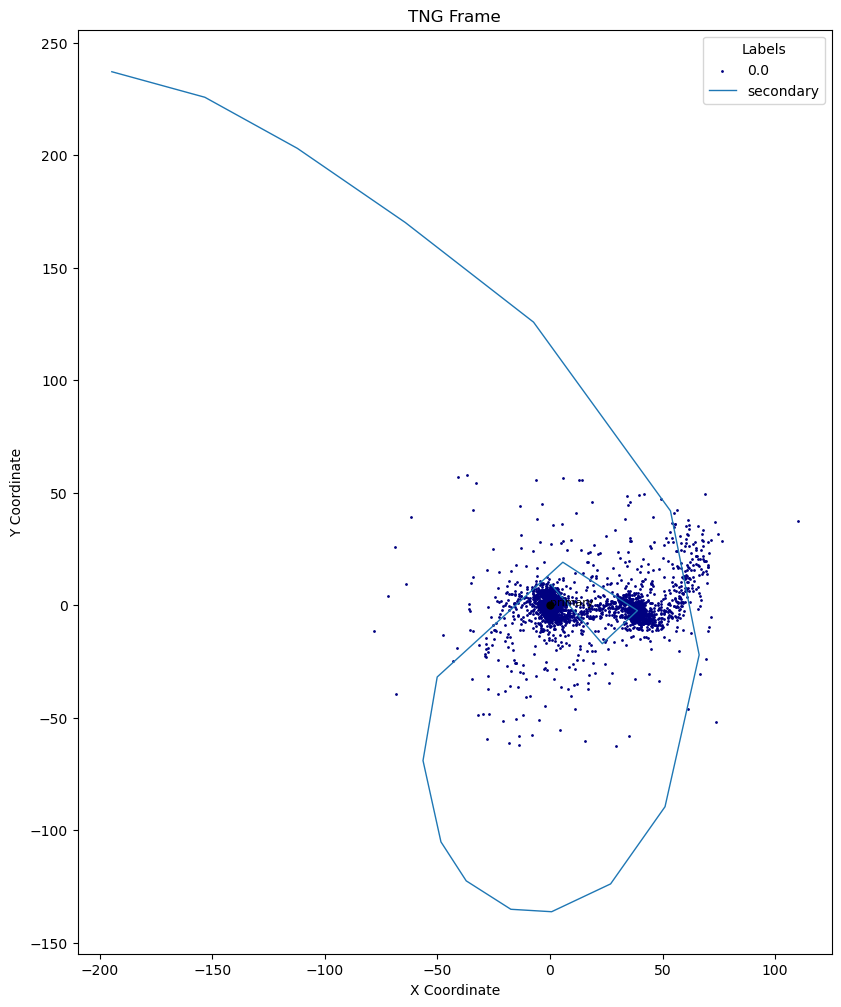

In [12]:
def get_moving_path( t_row, t_df, dev_print = False ):

    LOGGER.debug("Getting TNG orbit...")

    # Get the final position and velocity in frame
    p_pos = t_row['p_SubhaloPos_orbital_frame']
    s_pos = t_row['s_SubhaloPos_orbital_frame']
    p_vel = t_row['p_SubhaloVel_orbital_frame']
    s_vel = t_row['s_SubhaloVel_orbital_frame']

    # Get the tranform needed to convert to orbital frame
    pos_transform = t_row['orbital_frame_pos_transform']
    vel_transform = t_row['orbital_frame_vel_transform']

    # Get raw position and velocity data
    p_path_raw_pos = np.stack(t_df['p_SubhaloPos'].values)
    s_path_raw_pos = np.stack(t_df['s_SubhaloPos'].values)
    p_path_raw_vel = np.stack(t_df['p_SubhaloVel'].values)
    s_path_raw_vel = np.stack(t_df['s_SubhaloVel'].values)

    if dev_print:

        print(f"positions type: {type(p_pos)}")
        print(f"Primary Position: {p_pos}")
        print(f"Secondary Position: {s_pos}")
        print(f"Primary Velocity: {p_vel}")
        print(f"Secondary Velocity: {s_vel}")

        print( f"tranform type: {type(pos_transform)}" )
        print( f"Position Transform: \n{pos_transform}" )
        print( f"Velocity Transform: \n{vel_transform}" )

        print( f"Raw Position Type: {type(p_path_raw_pos)}" )
        print( f"Raw Position Data: {p_path_raw_pos.shape}" )
        print( f"Raw Velocity Data: {p_path_raw_vel.shape}" )
    
    p_path_pos = tf.apply_transformation( pos_transform, p_path_raw_pos )
    s_path_pos = tf.apply_transformation( pos_transform, s_path_raw_pos )
    p_path_vel = tf.apply_transformation( vel_transform, p_path_raw_vel )
    s_path_vel = tf.apply_transformation( vel_transform, s_path_raw_vel )

    p_path = np.hstack( [p_path_pos, p_path_vel])
    s_path = np.hstack( [s_path_pos, s_path_vel])

    if dev_print:
        print( f"Transformed Primary Data: {p_path.shape}" )
        print( f"Transformed Secondary Data: {s_path.shape}")
    
    return p_path, s_path

def convert_to_fixed_frame(primary, secondary):
    """
    Convert the orbital paths and velocities to a frame where the primary galaxy is fixed at the origin.

    Args:
    - primary (np.ndarray): Nx6 array of primary galaxy positions and velocities [ x y z vy vy vz ].
    - secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities [ x y z vy vy vz ].

    Returns:
    - fixed_secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary.shape == secondary.shape

    # Convert to fixed frame
    fixed_secondary = secondary - primary

    return fixed_secondary

def convert_to_moving_frame(primary_moving, secondary_fixed):
    """
    Convert the paths and velocities from a fixed primary frame back to the original moving frame.

    Args:
    - primary_moving (np.ndarray): Nx6 array of primary galaxy positions and velocities [x, y, z, vx, vy, vz].
    - secondary_fixed (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.

    Returns:
    - secondary_moving (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the moving frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary_moving.shape == secondary_fixed.shape, "Primary and fixed secondary arrays must have the same shape"
    assert primary_moving.shape[1] == 6, "Each row should contain 6 elements: [x, y, z, vx, vy, vz]"

    # Convert to moving frame
    secondary_moving = secondary_fixed + primary_moving

    return secondary_moving

if buildEnv and True:

    logger.setLevel(logging.INFO)

    path = {}

    p_path, s_path = get_moving_path( t_row, t_df, dev_print = True )

    path['p_moving'] = p_path
    path['s_moving'] = s_path

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
    pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
    pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']

    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )

    print( pts_tu[:,0:2].shape ) 
    print( pts_tu[:,-2].shape)

    tf.xy_plot( 
        xy_pts = pts_tu[:,0:2],
        plot_lines = path['s_fixed'][7:] , plot_labels=['secondary'], 
        sig_pts=np.array([[0,0,0]]), sig_labels=np.array(['primary']),
        title="TNG Frame", figsize=(12,12), std_dev = 5 )


Time:2024-12-13 13:56:14,055 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


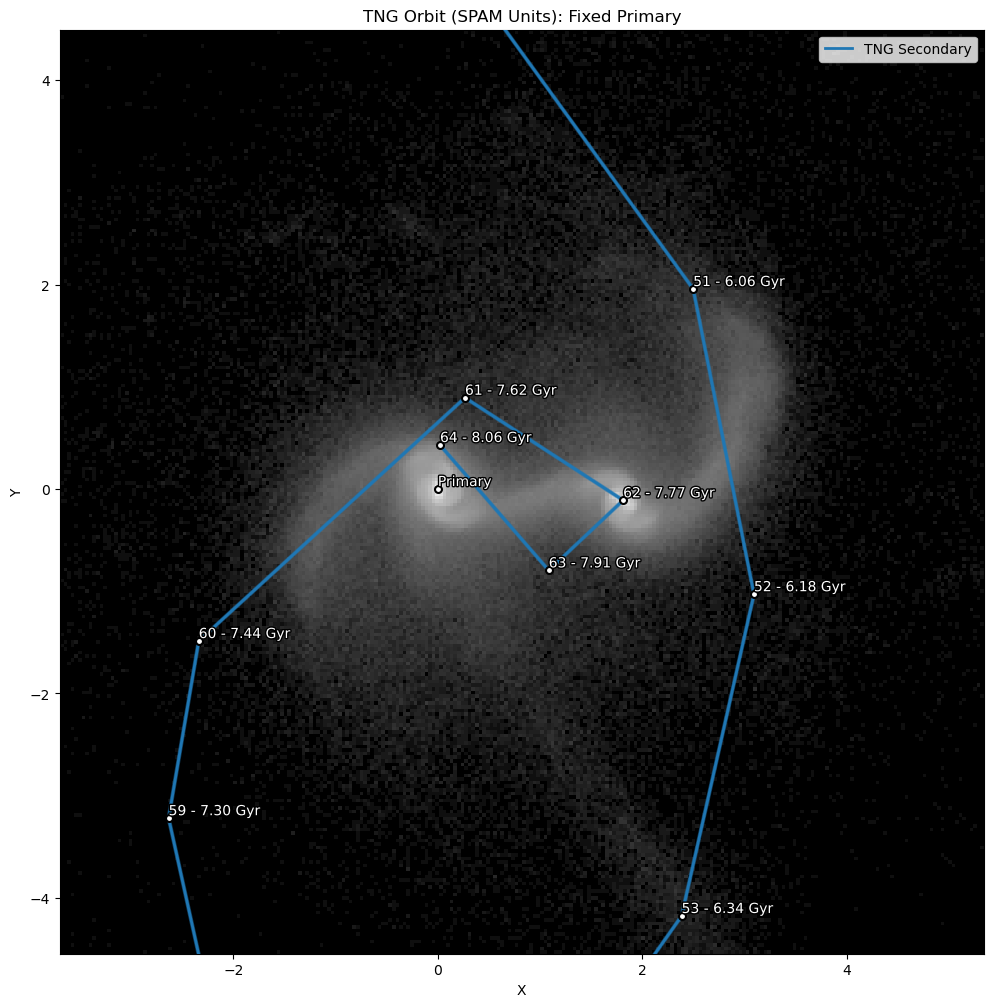

In [13]:
import matplotlib.patheffects as path_effects

def xy_histogram( hist_data,
                plot_data = None, plot_labels = None,
                annotations = None,
                limits = None,
                ext_ax=None,  title="2D Histogram", \
                std_dev=3, bins=256, cmap='gray', \
                log_scale=True, dim_inner = -1, \
                show_labels=False, plotting=True, figsize=None):
    """
    Plots a 2D histogram on a given axis with x and y limits set to n standard deviations.

    Args:
    hist_data (np.ndarray): An N x 2 array of xy coordinates.
    plot_data (list or np.ndarray): Optional. List of N x 2 arrays or a single N x 2 array of xy coordinates to overlay on the histogram.
    plot_labels (list or str): Labels for each plot_data item.
    annotations (list of tuples): List of (location, text) tuples. Each location is an xy coordinate, and text is a string to annotate.
    limits (tuple): Axis limits for x and y.
    ax (matplotlib.axes.Axes or None): The axis to plot on. If None, a new figure and axis will be created.
    title (str): Title of the subplot.
    std_dev (float): Number of standard deviations to set axis limits.
    bins (int): Number of bins along each axis in the histogram.
    cmap (str): Colormap for the histogram.
    log_scale (bool): Whether to apply logarithmic scaling to the histogram.
    dim_inner (int): Threshold for capping high histogram bin counts.
    show_labels (bool): Whether to show axis labels.
    plotting (bool): If true, shows the plot.
    """

    LOGGER.info("Plotting 2D Histogram...")
    LOGGER.debug("Hist Data %s", str(hist_data.shape))

    if hist_data is None:
        LOGGER.error("hist_data cannot be None")
        raise ValueError("hist_data cannot be None")
    

    # Ensure plot_data and plot_labels are lists
    if plot_data is not None and not isinstance(plot_data, list):
        plot_data = [plot_data]
    if plot_labels is not None and not isinstance(plot_labels, list):
        plot_labels = [plot_labels]


    # If ax is None, create a new figure and axis
    ax = ext_ax or plt.subplots(figsize=figsize)[1]

    # Calculate the mean and standard deviation
    mean_xy = np.mean(hist_data[:, 0:2], axis=0)
    std_xy  = np.std( hist_data[:, 0:2], axis=0)

    # Determine the maximum range to use for both axes
    max_range = np.max(std_xy) * std_dev

    # Set axis limits to be the same for both x and y
    if limits is None:
        xlim = (mean_xy[0] - max_range, mean_xy[0] + max_range)
        ylim = (mean_xy[1] - max_range, mean_xy[1] + max_range)
    else:
        xlim = limits[0]
        ylim = limits[1]

    # Create the histogram
    h, xedges, yedges, image = ax.hist2d(hist_data[:, 0], hist_data[:, 1], bins=bins, range=[xlim, ylim], cmap=cmap)
    
    # 
    if dim_inner != -1:
        
        # Calculate the mean and standard deviation of the histogram bin counts
        mean_bin_count = np.mean(h)
        std_bin_count = np.std(h)

        # Set a threshold to cap the brightest regions
        threshold = mean_bin_count + dim_inner * std_bin_count  # You can adjust this multiplier

        # Apply the threshold to cap the values in the histogram
        h[h > threshold] = threshold  # Cap all bin counts above the threshold

    
    # Apply log1p to enhance visibility of low count regions
    if log_scale:
        h = np.log1p(h)  

    # Clear the axis and plot with modified histogram data
    ax.clear()
    image2 = ax.imshow(h.T, interpolation='nearest', origin='lower', aspect='auto',
                      extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                      cmap=cmap)
    
    # Plot each set of plot_data with a unique color and label
    if plot_data is not None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(plot_data)))  # Choose colors from tab10 colormap
        for i, data in enumerate(plot_data):
            label = plot_labels[i] if plot_labels and i < len(plot_labels) else f"Data {i+1}"
            ax.plot(data[:, 0], data[:, 1], color=colors[i], linewidth=2, zorder=5, label=label)
            ax.plot(data[:, 0], data[:, 1], color=colors[i], linewidth=3, zorder=4, alpha=0.5)

        # Show legend
        ax.legend()
    
    # Annotate data points with large white points and text with a black outline
    if annotations is not None:
        for location, text in annotations:
            # Check if the annotation is within the plot bounds
            if xlim[0] <= location[0] <= xlim[1] and ylim[0] <= location[1] <= ylim[1]:
                ax.scatter(*location, color='white', s=25, edgecolor='black', linewidth=1.5, zorder=6)  # Large white point with black outline
                text_obj = ax.text(location[0], location[1], text, fontsize=10, color='white',
                                ha='left', va='bottom', zorder=7)
                # Apply a black outline to text
                text_obj.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])


    # Set titles and labels
    ax.set_title(title)
    
    if show_labels:
        # Add axis labels and ticks (they are no longer removed)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    else:   
        # Remove the axis labels and ticks
        ax.set_xticks([])
        ax.set_yticks([])
    
    ax.legend()

    # Set axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')

    # If ax was None, display the plot
    if ax is None:
        plt.show()

    # Enforce square aspect ratio
    ax.set_aspect('equal')
    
    return

if buildEnv and True:

    # convert tng pts to spam units
    pts_su = np.copy( pts_raw )
    pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
    pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

    # Convert the paths to SPAM units
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    path['times_su'] = convert_time_tng_to_spam( path['times'] )

    # Create list of tuples from secondary fixed path and snap data
    base_annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]

    # Add origin as primary galaxy
    base_annotate_data.append( ([0,0], 'Primary') )

    xy_histogram( \
        pts_su, \
        path['s_fixed_su'], 'TNG Secondary', \
        show_labels = True, std_dev = 4,
        annotations = base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary',
        figsize=(12,12)
    )

## Creating Splines

So, I want to study the TNG orbit between snapshots, specifically the moments of closest approach aka fly-by events.  Splines are a common way to interpolate between points, so let's create a spline for the TNG data. 


Time:2024-12-13 13:56:15,789 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


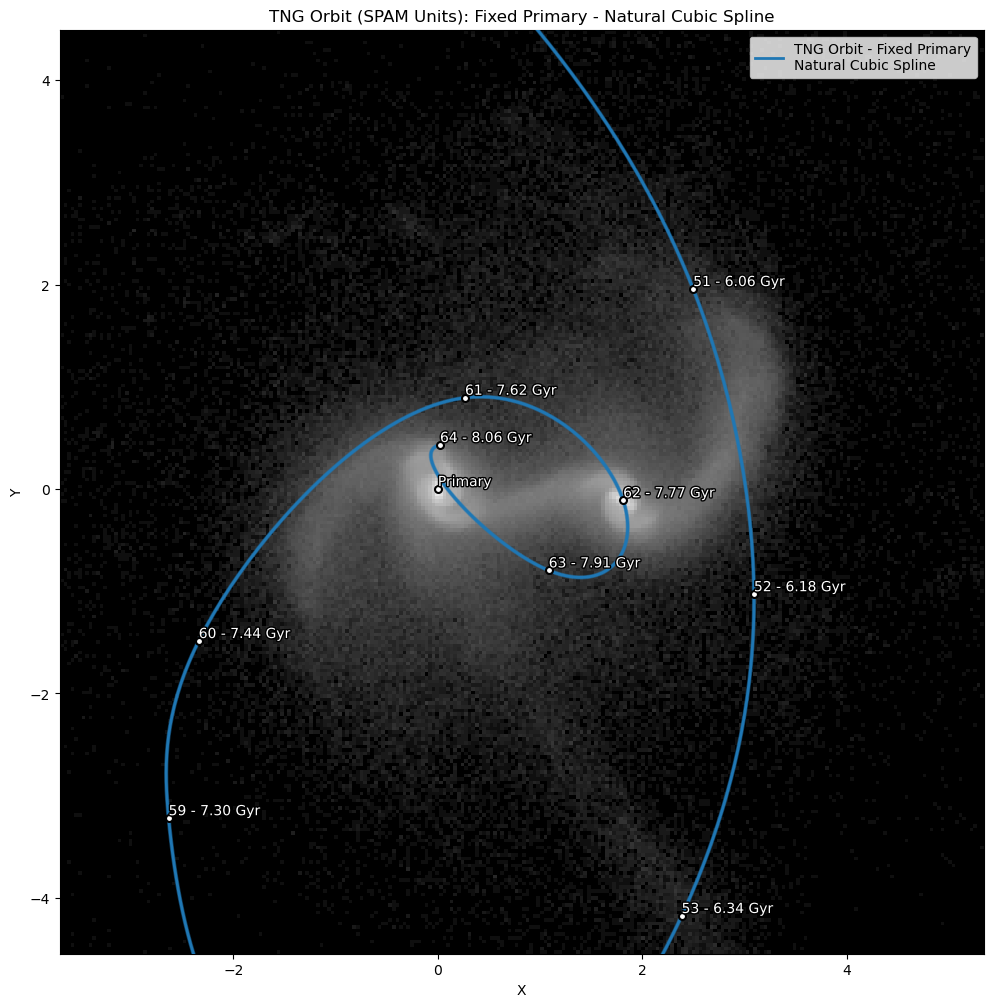

In [14]:
def interpolate_path_natural_cubic(times, path):

    LOGGER.debug("Interpolating path with natural cubic splines...")

    # Extract positions and velocities
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create cubic splines with clamped boundary conditions using endpoint velocities
    spline_x = CubicSpline(times, x, bc_type=((1, dx[0]), (1, dx[-1])))
    spline_y = CubicSpline(times, y, bc_type=((1, dy[0]), (1, dy[-1])))
    spline_z = CubicSpline(times, z, bc_type=((1, dz[0]), (1, dz[-1])))

    # Add the splines and their derivative functions to a list
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines

if buildEnv and True:

    # Create cubic splines
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])

    # Generate a test set of times
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )

    # Evaluate the splines at the test times
    path['s_fixed_su_cubic_nat_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_nat_func']] for t in path['s_times_test'] ])

    # Send to histogram 
    xy_histogram( \
        pts_su, \
        path['s_fixed_su_cubic_nat_test'], 'TNG Orbit - Fixed Primary\nNatural Cubic Spline', \
        show_labels = True, std_dev = 4,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Natural Cubic Spline',
        figsize=(12,12)
    )


Time:2024-12-13 13:56:17,914 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


Time:2024-12-13 13:56:18,560 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 13:56:19,011 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


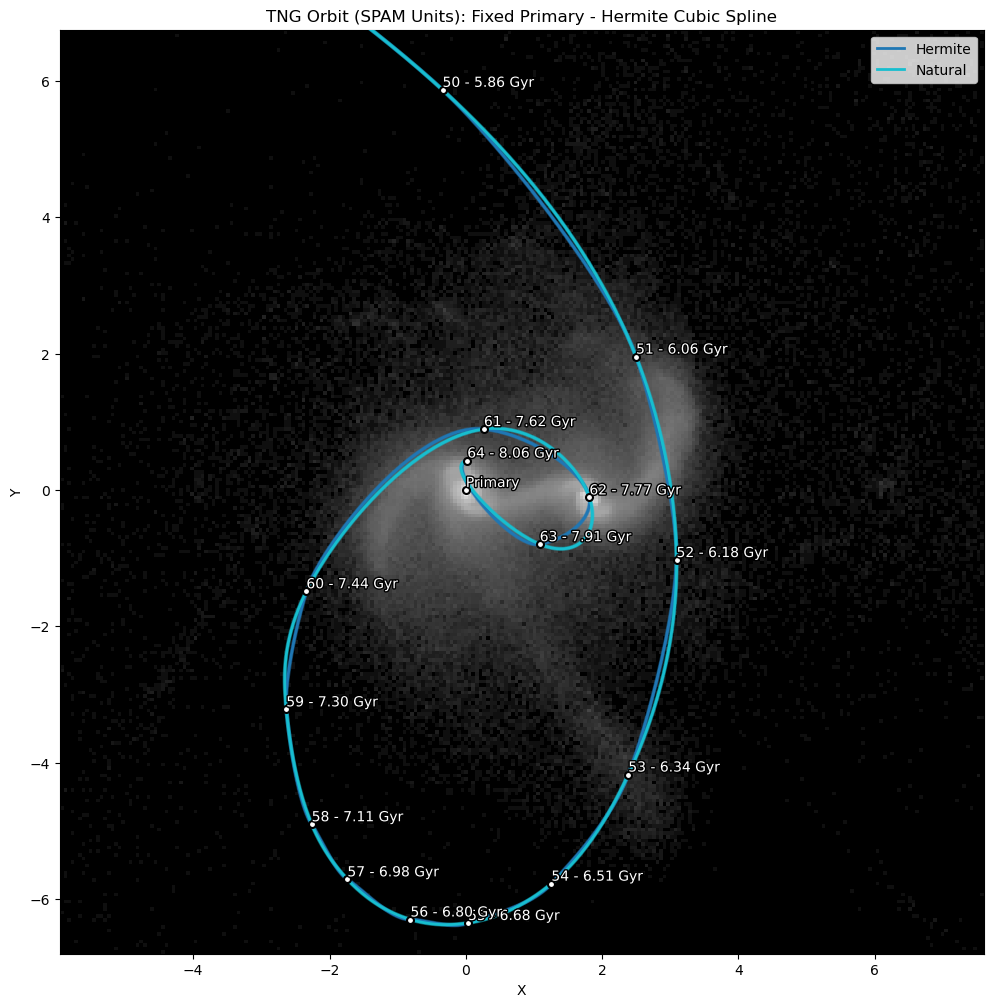

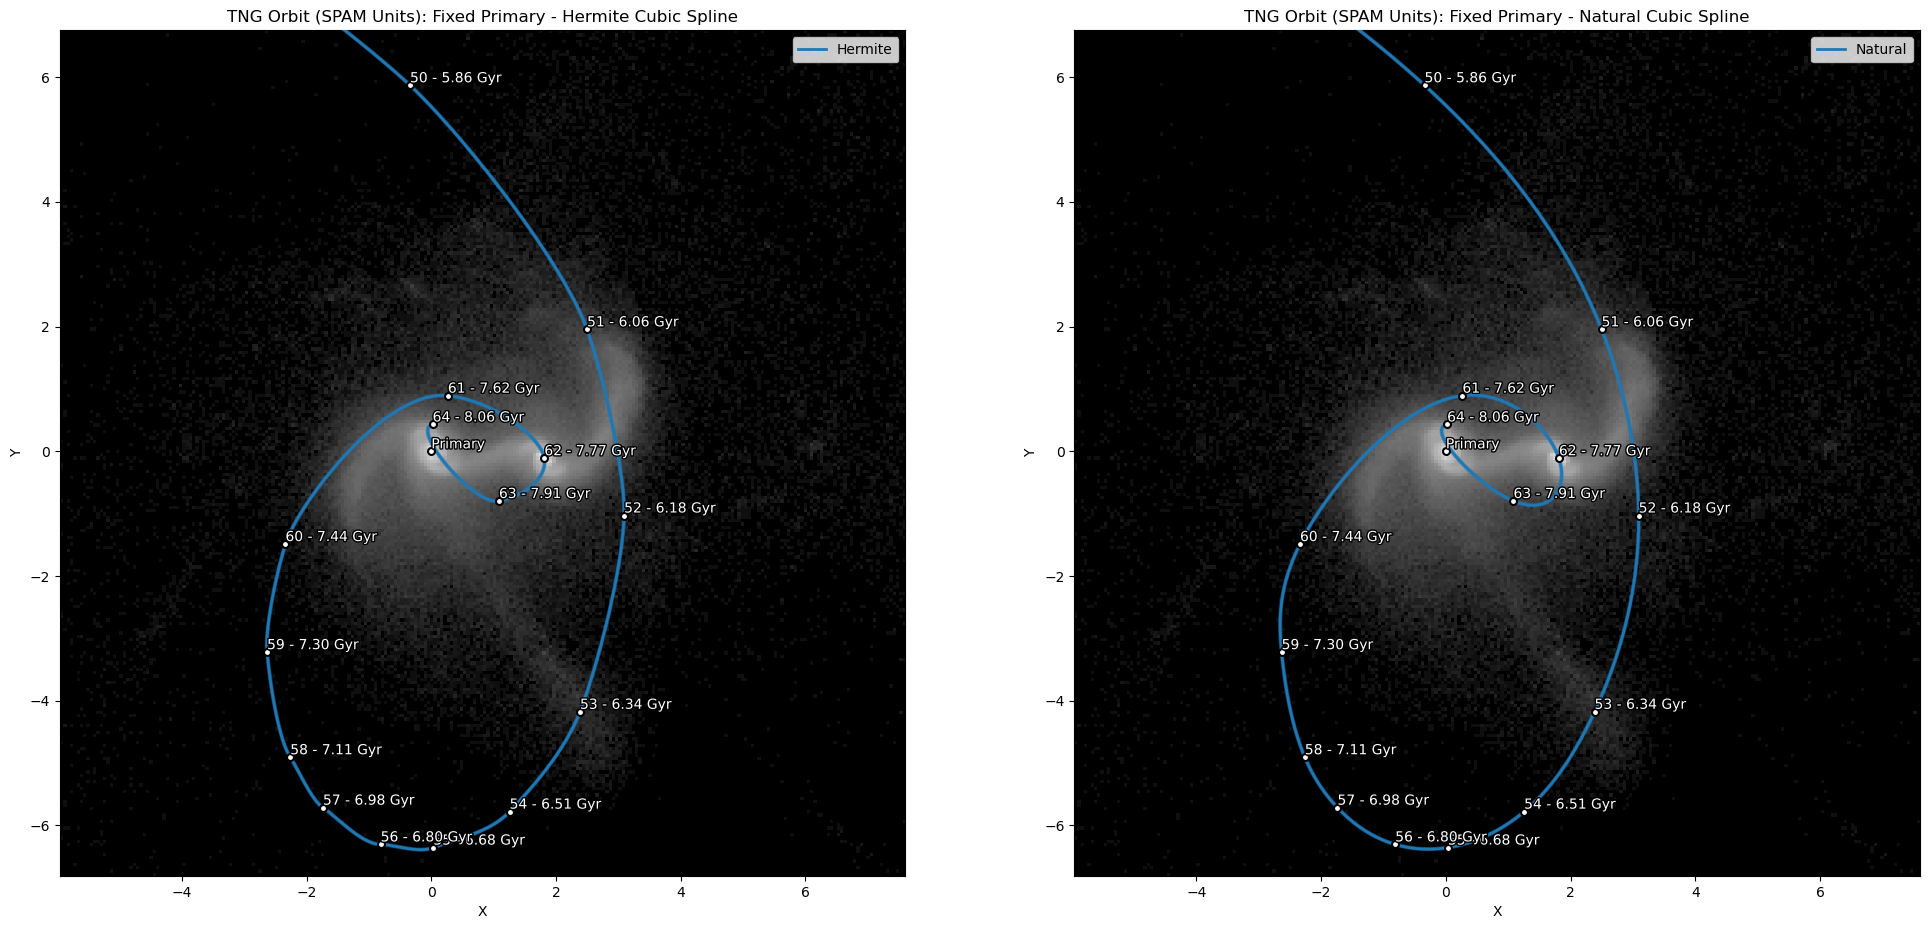

In [15]:
from scipy.interpolate import CubicHermiteSpline

def interpolate_path_with_velocities(times, path):

    LOGGER.debug("Interpolating path with Hermite cubic splines...")

    # Separate positions and velocities into x, y, z components
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create Hermite splines for each dimension
    spline_x = CubicHermiteSpline(times, x, dx)
    spline_y = CubicHermiteSpline(times, y, dy)
    spline_z = CubicHermiteSpline(times, z, dz)

    # Create list of splines and their derivative functions
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines

if buildEnv and True:

    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])

    plots = [path['s_fixed_su_cubic_herm_test'],path['s_fixed_su_cubic_nat_test']]
    plot_labels = ['Hermite', 'Natural']

    
    base_plot_list = [path['s_fixed_su_cubic_herm_test']]
    base_plot_labels = ['Hermite']
    sd = 6

    # # Send to histogram 
    xy_histogram( \
        pts_su, \
        plots, plot_labels, \
        show_labels = True, std_dev = sd,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Hermite Cubic Spline',
        figsize=(12,12)
    )
    
    # Create two subplots left and right
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))
    
    # Feed one plot to each subplot with the same pts data
    xy_histogram( \
        pts_su, \
        plots[0], plot_labels[0], \
        show_labels = True, std_dev = sd,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Hermite Cubic Spline',
        ext_ax = axs[0]
    )

    xy_histogram( \
        pts_su, \
        plots[1], plot_labels[1], \
        show_labels = True, std_dev = sd,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Natural Cubic Spline',
        ext_ax = axs[1]
    )


## Analysing Splines

According to ChatGPT, Hermites require positions and velocities to be perfect matches, but this makes the curve look unnatural to me, like it's focusing on connecting dots. It might be using abrupt changes in accelatation to accomplish this.  Natural cubic's on the other hand, do their best to minimize acceleration and thus smooths velocity and acceleration.  Which makes it look intuitively smoother but it does make the velocity data less accurate for a few points.  I also played around with estimating accelerations and creating a quintic spline...  This was even jerkier and worse than the hermite....

Thankfully, while directly comparing the Hermite and natural spline, there does not appear to be any large differences in position/velocity (Except at the very end when they merge, and accelerations are crazy.  Which is not a focus).  And given the spline is an interpolation in the first place, there will always be a bit of error between points no matter which inpertoloation I use. 

**(NO MORE SPLINES MATTHEW)**
---
---

In [16]:
if buildEnv:
    
    base_plot_list = [path['s_fixed_su_cubic_herm_test']]
    base_plot_labels = ['Hermite']

## Wrapper for TNG to SPAM conversion and misc data conversion


Primary ID: 62000000190717
MOI_2: 67000000184181
Target idx: 23
Target DF: 26

Target Row:
moi_2                                                              67000000184181
snap                                                                           62
merger_snap                                                                  65.0
p_moi_1                                                          50000000220008.0
s_moi_1                                                          50000000220010.0
                                                      ...                        
ss_SubhaloSpin_orbital_frame    [-703.8460704236377, 612.369167093556, -5810.4...
img_name_1                                              Target_62000000190717.png
moi_4_rating                                                                    5
times_su                                                                89.692138
idx                                                                            23
Name: 2

Time:2024-12-13 13:56:25,803 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


Loaded Pts: (2389408, 10)
Done


Time:2024-12-13 13:56:26,242 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


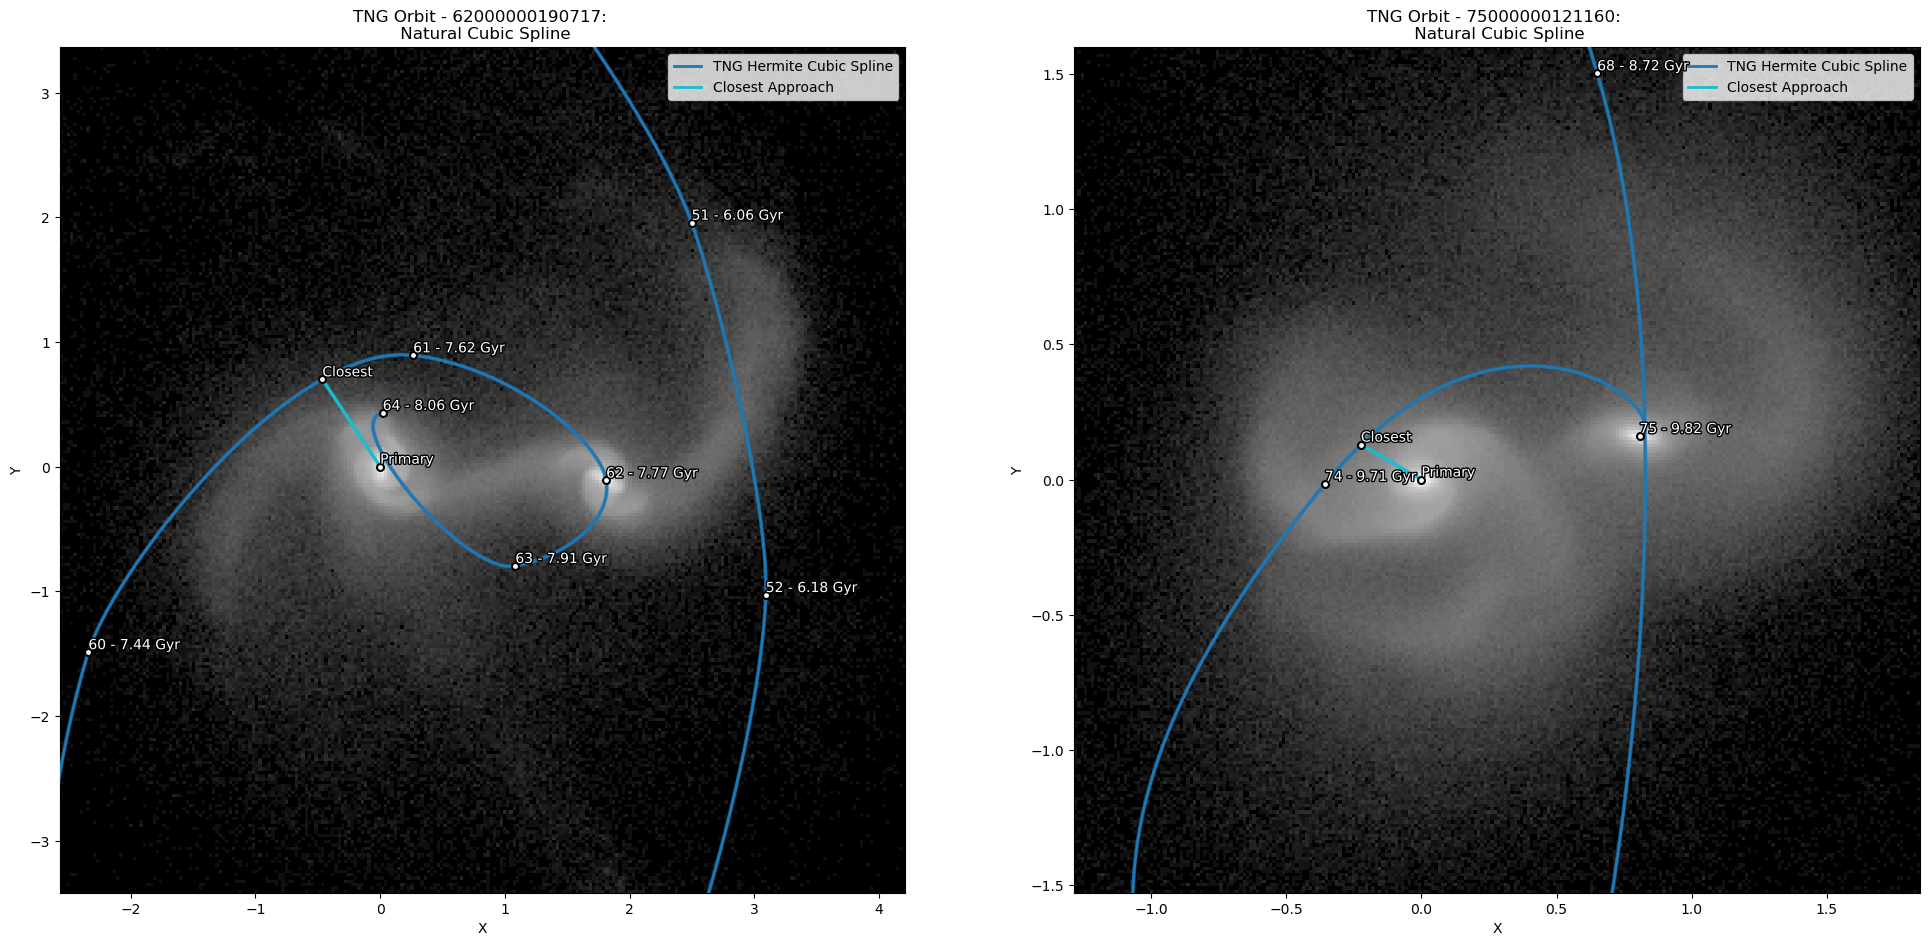

In [17]:
def get_tng_target_orbit( p_id, 
                      file_path = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl',
                      dev_print = False,
                      ):
    
    LOGGER.debug("Getting TNG target orbit...: %s", str(p_id))
    
    # Load Target Dynamics over time
    tng_targets = pd.read_pickle( file_path )
    t_row, t_df = extractTargetData( p_id, tng_targets, dev_print = dev_print )

    # Extract path
    p_path, s_path = get_moving_path( t_row, t_df )

    path = {}
    path['p_moving'] = p_path
    path['s_moving'] = s_path
    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )
    
    path['current_snap'] = t_row['snap']
    path['current_snap_idx'] = t_row['idx']
    path['current_snap_time'] = t_row['time_gyr']

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )

    # Convert the paths to SPAM units
    path['times_su'] = convert_time_tng_to_spam( path['times'] )
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    
    # Create Splines for plotting
    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])
    path['s_fixed_su_cubic_nat_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_nat_func']] for t in path['s_times_test'] ])

    # Using spline tests, Go backwards in time from the current position, and the point of closest to approach
    # This will be the point where the secondary galaxy is closest to the primary galaxy
    current_time = convert_time_tng_to_spam( t_row['time_gyr'] )    # Get current moment in time
    current_idx = np.argmin( np.abs( path['s_times_test'] - current_time ) )    # Find idx for current time
    current_pos = path['s_fixed_su_cubic_herm_test'][current_idx,0:3]     # Get current position
    current_dist = np.linalg.norm( current_pos )    # Get current distance  Note origin is primary galaxy position
    current_time = path['s_times_test'][current_idx]
    
    # While distance descrease, keep going back in time
    moving_idx = current_idx - 1
    prev_dist = current_dist

    # Add condition to continue to move back in time in case they were converging
    keep_moving = True

    # Find most recent location of closest approach
    while True:
        if moving_idx < 0:  break        # Hard break limit
        moving_pos = path['s_fixed_su_cubic_herm_test'][moving_idx,0:3]
        moving_dist = np.linalg.norm( moving_pos )

        # Just in case the galaxies were converging at current time, go backwards until they were diverging after closest approach
        if keep_moving and moving_dist > prev_dist:
            prev_dist = moving_dist
            moving_idx -= 1
            continue
        else:
            keep_moving = False

        # Found the point of closest approach, (Assuming smooth local minima)
        if moving_dist > prev_dist :
            closest_idx = moving_idx
            break

        prev_dist = moving_dist
        moving_idx -= 1
    
    # Just in case the closest approach wasn't smooth, double the time range to ensure we get a good section surrounding the closest approach
    past_idx = current_idx - 2*( current_idx - closest_idx )
    if past_idx < 0: past_idx = 0

    # Using the closest index, get the closest position
    path['current_idx'] = current_idx
    path['current_pos'] = current_pos
    path['current_time'] = current_time
    path['closest_idx'] = closest_idx
    path['closest_pos'] = path['s_fixed_su_cubic_herm_test'][closest_idx,0:3]
    path['closest_time'] = path['s_times_test'][closest_idx]
    path['past_idx'] = past_idx
    path['past_pos'] = path['s_fixed_su_cubic_herm_test'][past_idx,0:3]
    path['past_time'] = path['s_times_test'][past_idx]

    path['past_dt'] = path['closest_time'] - path['past_time']
    path['current_dt'] = path['current_time'] - path['closest_time']

    if dev_print:
        print(f"Test Spline: {path['s_fixed_su_cubic_herm_test'].shape}")
        print(f"Current: {current_idx} - {current_time:.2f}")
        print(f"Closest: {closest_idx} - {path['closest_time']:.2f}")
        print(f"Past: {past_idx} - {path['past_time']:.2f}")
        print(f"Past dt: {path['past_dt']:.2f}")
        print(f"Current dt: {path['current_dt']:.2f}")

    # Starting from current snapshot, go back in time until you find a snapshot before the closest approach
    for i in range( int(path['current_snap_idx']), 0, -1 ):
        t = path['times_su'][i]
        if dev_print: print( f" - {i} - {path['snaps'][i]} - {t:.2f} < {path['closest_time']:.2f}" )
        if t < path['closest_time']:
            j = i-1 # Do two snapshots back to ensure tidal forces are not too strong
            path['snap_before_closest_approach_orbit_idx'] = j
            path['snap_before_closest_approach'] = path['snaps'][j]
            path['snap_before_closest_approach_time'] = path['times_su'][j]
            break  # Break when found
        

    if dev_print:
        print( f"Current: {t_row['snap']} - {current_idx} - {current_pos} - {current_time} - " )
        print( f"Closest: {closest_idx} - {path['closest_pos']} - {path['closest_time']}" )
        if path['past_time'] > path['snap_before_closest_approach_time']:
            print( f"Past: {past_idx} - {path['past_pos']} - {path['past_time']}" )
            print( f"Snap Before Closest Approach: {path['snap_before_closest_approach']} - {path['snap_before_closest_approach_time']}" )
        else:
            print( f"Snap Before Closest Approach: {path['snap_before_closest_approach']} - {path['snap_before_closest_approach_time']}" )
            print( f"Past: {past_idx} - {path['past_pos']} - {path['past_time']}" )
    
    # Generate arrays for feeding into spam
    path['tng_ar_v1'] = standardize_tng_parameters_v1( t_row, )
    path['spam_ar_v1'] = convert_units_tng_to_spam( path['tng_ar_v1'] )
    path['tng_ar_v2'] = standardize_tng_parameters_v2( t_df, path['current_snap'], path['snap_before_closest_approach'] )
    path['spam_ar_v2'] = convert_units_tng_to_spam( path['tng_ar_v2'] )

    # Add function for generating new arrays with different radius scales
    def gen_new_spam_arrays( radius_scale = 1.0, ):
        tmp_ar = standardize_tng_parameters_v1( t_row, radius_scale = radius_scale )
        ar_v1 = convert_units_tng_to_spam( tmp_ar )
        tmp_ar = standardize_tng_parameters_v2( t_df, path['current_snap'], path['snap_before_closest_approach'], radius_scale = radius_scale )
        ar_v2 = convert_units_tng_to_spam( tmp_ar )
        return ar_v1, ar_v2
    path['gen_new_spam_arrays'] = gen_new_spam_arrays

    if dev_print:
        print( f"V1: {path['tng_ar_v1']}" )
        print( f"V2: {path['tng_ar_v2']}" )
        print(f"Diff: {np.sum( np.abs( path['tng_ar_v1'] - path['tng_ar_v2'] ) )}")

    # Create list of tuples to annotate the plot
    base_annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]
    path['annotations_base'] = base_annotate_data
    path['annotations'] = base_annotate_data.copy()
    path['annotations'].append( ([0,0], 'Primary') )
    path['annotations'].append( (path['s_fixed_su_cubic_herm_test'][closest_idx,0:2], 'Closest') )

    # Create plot []
    path['plot_list_base'] = [path['s_fixed_su_cubic_herm_test'],]
    path['plot_labels_base'] = ['TNG Hermite Cubic Spline']

    # Add a line between the origin and the closest point
    path['plot_list_base'].append( np.array([ [0,0,0], path['s_fixed_su_cubic_herm_test'][closest_idx,0:3] ]) )
    path['plot_labels_base'].append('Closest Approach')

    # Create new lists for future plotting
    path['plot_list'] = path['plot_list_base'].copy()
    path['plot_labels'] = path['plot_labels_base'].copy()

    # Add the Series and DataFrame to the path for convenience
    path['current_info'] = t_row
    path['all_info'] = t_df

    # Add function for resetting the plot info
    def reset_plot_info():
        path['plot_list'] = path['plot_list_base'].copy()
        path['plot_labels'] = path['plot_labels_base'].copy()
        path['annotations'] = path['annotations_base'].copy()
        return path
    
    path['reset_plot_info'] = reset_plot_info

    return path

def get_tng_target_pts(t_row, p_id = None, dev_print = False,         
           pts_dir = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-data/',
           ):

    if p_id is None:
        p_id = t_row['p_SubhaloIDRaw']

    LOGGER.debug("Getting TNG target pts...: %s", str(p_id))

    # Load Pts
    try:
        pts_raw = load_pts_data( p_id, data_dir = pts_dir )    
        pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
        pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']
        pts_su = np.copy( pts_tu )
        pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
        pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

        if dev_print:
            print( f"Loaded Pts: {pts_su.shape}" )

        return pts_su
    except:
        return None

if buildEnv:
    
    # Target Unique IDs
    p1 = 62000000190717 
    p2 = 75000000121160 

    # TNG target data
    tng_target_1 = get_tng_target_orbit( p1, dev_print = True, )
    tng_target_2 = get_tng_target_orbit( p2, dev_print = False )
    
    # TNG Target particles
    tng_target_1['pts'] = get_tng_target_pts( tng_target_1['current_info'], dev_print = True )
    tng_target_2['pts'] = get_tng_target_pts( tng_target_2['current_info'], dev_print = True )

    # Create two subplots left and right
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))

    print("Done")
    
    # Feed one plot to each subplot with the same pts data
    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'TNG Orbit - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}: \n Natural Cubic Spline',
        ext_ax = axs[0]
    )

    xy_histogram( \
        tng_target_2['pts'] , \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'TNG Orbit - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}: \n Natural Cubic Spline',
        ext_ax = axs[1]
    )

    plt.show()


---
# Let's actually test if the TNG to SPAM unit conversion works
---

Time:2024-12-13 13:56:28,356 - [new_simulator.orbit_run_wrapper] - INFO - Running SPAM Simulation - Orbit Run
Time:2024-12-13 13:56:28,358 - [new_simulator.orbit_run_wrapper] - DEBUG - Calling custom_runs.calc_orbit_time_steps: [ 1.81e+00 -1.10e-01  1.80e-08  8.99e-02 -6.00e-01 -1.25e-01  8.37e+00
  7.73e-01  5.96e-01  6.29e-01  7.89e+01  1.39e+02  1.60e+02  1.71e+02
  5.96e-02  6.29e-02  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00]
Time:2024-12-13 13:56:30,580 - [new_simulator.orbit_run_wrapper] - DEBUG - Calling custom_runs.orbit_run.  Time steps: 5086
Time:2024-12-13 13:56:32,789 - [new_simulator.orbit_run_wrapper] - DEBUG - Adjusting Orbit Path by Time: 89.68289815795069
Time:2024-12-13 13:56:32,791 - [new_simulator.orbit_run_wrapper] - DEBUG - Returned Orbit Path: (5086, 7)
Time:2024-12-13 13:56:32,793 - [new_simulator.orbit_run_wrapper] - INFO - Running SPAM Simulation - Orbit Run
Time:2024-12-13 13:56:32,795 - [new_simulator.orbit_run_wrapper] - DEBUG - Calling c

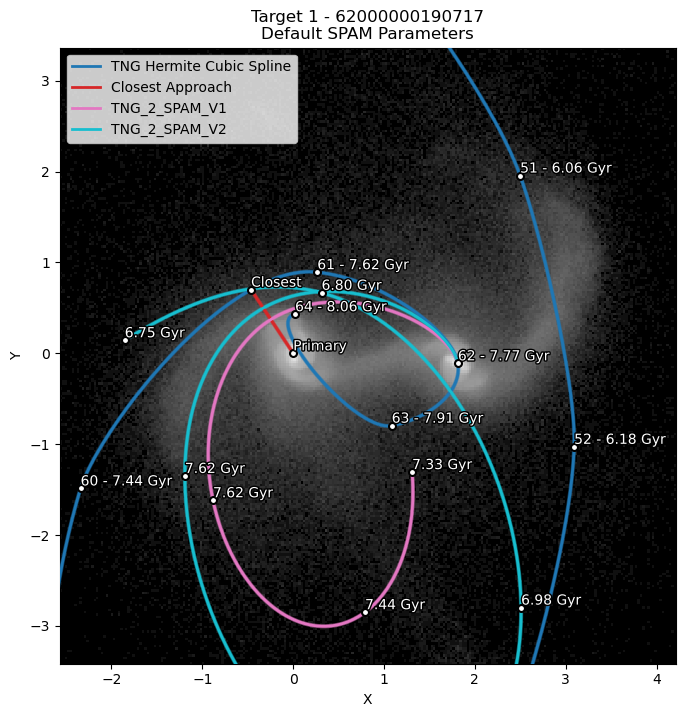

Time:2024-12-13 13:56:44,813 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 13:56:44,814 - [2561079244.xy_histogram] - DEBUG - Hist Data (2389408, 10)


<Figure size 640x480 with 0 Axes>

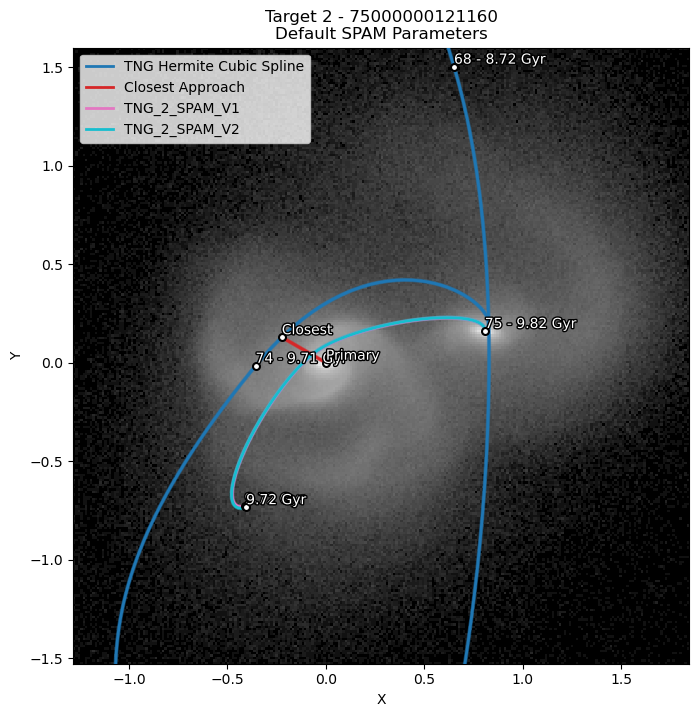

In [18]:
def add_spam_orbit_info( spam_orbit, tng_target, spam_run_name = 'SPAM Orbit', add_to_target = False, add_to_base = False ):

    new_annotations = tng_target['annotations'].copy()
    new_plot_list = tng_target['plot_list'].copy()
    new_plot_labels = tng_target['plot_labels'].copy()

    # If that spam name already exists in the plot labels, remove it and add the new one
    if spam_run_name in new_plot_labels:
        idx = new_plot_labels.index( spam_run_name )
        new_plot_list.pop( idx )
        new_plot_labels.pop( idx )
    
    # Add Spam orbit to plot list
    new_plot_list.append( spam_orbit )

    # If name is provided, add to labels
    if spam_run_name is not None:
        new_plot_labels.append( spam_run_name )
    else:
        new_plot_labels.append( 'SPAM Orbit' )

    # Always add first Starting position to annotations
    new_annotations.append( ( spam_orbit[0, 0:2], f"{convert_time_spam_to_tng(spam_orbit[0,-1]):.2f} Gyr") )

    # Find where spam orbit is at snapshot times.
    for i,t in enumerate(tng_target['times_su']):

        # Only add times that are within the spam orbit time range
        if t > spam_orbit[0,-1] and t < spam_orbit[-1,-1]:

             # Find index in spam orbit closest to time
            idx = np.argmin(np.abs(spam_orbit[:,-1] - t))

            # Add to annotations
            new_annotations.append( ( spam_orbit[idx, 0:2], f"{convert_time_spam_to_tng(t):.2f} Gyr") )

    # If you want to keep this plots around 
    if add_to_target:
        tng_target['annotations'] = new_annotations
        tng_target['plot_list'] = new_plot_list
        tng_target['plot_labels'] = new_plot_labels
    
    # If you want to add these to the base plots
    if add_to_base:
        tng_target['annotations_base'] = new_annotations
        tng_target['plot_list_base'] = new_plot_list
        tng_target['plot_labels_base'] = new_plot_labels
    
    return new_annotations, new_plot_list, new_plot_labels

if buildEnv:
    LOGGER.setLevel(logging.DEBUG)
    # Default SPAM simulations of TNG targets
    # These take a while, so only run if needed
    overwrite = False

    # If overwrite, renew tng targets
    if overwrite:
        tng_target_1 = tng_target_1['reset_plot_info']()
        tng_target_2 = tng_target_2['reset_plot_info']()
        
    if tng_target_1.get('spam_orbit_v1') is None or overwrite:
        tng_target_1['spam_orbit_v1'] = sim.orbit_run_wrapper( tng_target_1['spam_ar_v1'], current_time=tng_target_1['current_time'], spam_setup_params={} )
        _ = add_spam_orbit_info( tng_target_1['spam_orbit_v1'], tng_target_1, 'TNG_2_SPAM_V1', True, False )
    if tng_target_2.get('spam_orbit_v1') is None or overwrite:
        tng_target_2['spam_orbit_v1'] = sim.orbit_run_wrapper( tng_target_2['spam_ar_v1'], current_time=tng_target_2['current_time'] )
        _ = add_spam_orbit_info( tng_target_2['spam_orbit_v1'], tng_target_2, 'TNG_2_SPAM_V1', True, True )

    if tng_target_1.get('spam_orbit_v2') is None or overwrite:
        tng_target_1['spam_orbit_v2'] = sim.orbit_run_wrapper( tng_target_1['spam_ar_v2'], current_time=tng_target_1['current_time'] )
        _ = add_spam_orbit_info( tng_target_1['spam_orbit_v2'], tng_target_1, 'TNG_2_SPAM_V2', True )

    if tng_target_2.get('spam_orbit_v2') is None or overwrite:
        tng_target_2['spam_orbit_v2'] = sim.orbit_run_wrapper( tng_target_2['spam_ar_v2'], current_time=tng_target_2['current_time'] )
        _ = add_spam_orbit_info( tng_target_2['spam_orbit_v2'], tng_target_2, 'TNG_2_SPAM_V2', True, True )

    # Plot the new orbits

    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nDefault SPAM Parameters',
        # figsize=(12,12),
        figsize=(8,8),
    )
    
    plt.show()

    # clear plot for another plot
    plt.clf()

    xy_histogram( \
        tng_target_2['pts'] , \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nDefault SPAM Parameters',
        # figsize=(12,12),
        figsize=(8,8),
    )
    plt.show()


---
---
# TNG to SPAM Conversion Analysis

Looking at the TNG orbit and SPAM orbit from TNG parameters, we can see the orbits have roughly the same shape, but do not appear to overlap well.   Target 2 does better, but it's concerning how much they do not overlap.  

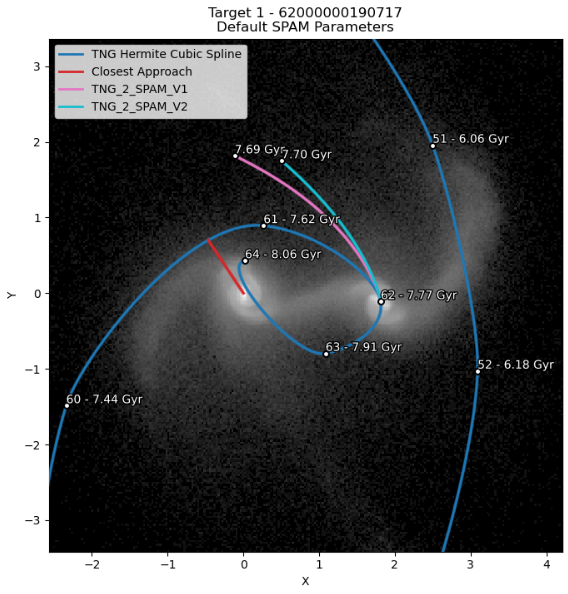
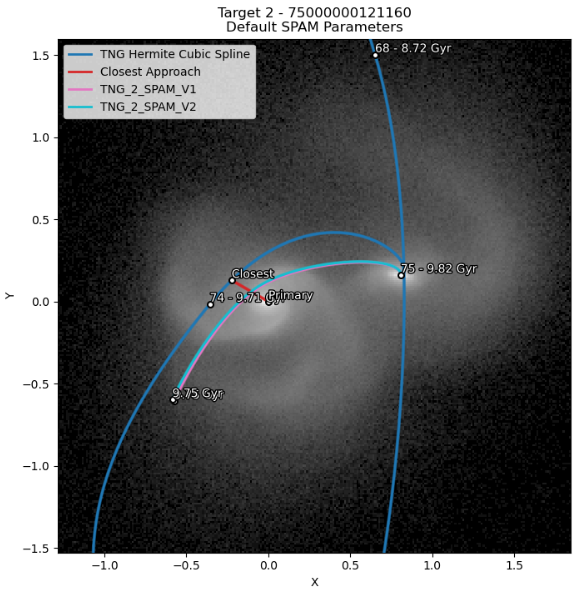


Let's see how well the tidal features match up.
---
---
---

Time:2024-12-13 13:56:45,987 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run
Time:2024-12-13 13:56:45,989 - [new_simulator.basic_run_wrapper] - DEBUG - Calling custom_runs.basic_disk: [ 1.81e+00 -1.10e-01  1.80e-08  8.99e-02 -6.00e-01 -1.25e-01  8.37e+00
  7.73e-01  5.96e-01  6.29e-01  7.89e+01  1.39e+02  1.60e+02  1.71e+02
  5.96e-02  6.29e-02  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00]
Time:2024-12-13 13:57:40,809 - [new_simulator.basic_run_wrapper] - DEBUG - Returned Disk Particles: (20001, 6) - (20001, 6)
Time:2024-12-13 13:57:40,813 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run
Time:2024-12-13 13:57:40,816 - [new_simulator.basic_run_wrapper] - DEBUG - Calling custom_runs.basic_disk: [ 1.81e+00 -1.10e-01  1.80e-08  8.99e-02 -6.00e-01 -1.25e-01  7.50e+00
  1.06e+00  4.56e-01  5.60e-01  4.14e+01  1.21e+02  1.65e+02  1.37e+02
  4.56e-02  5.60e-02  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.

SPAM Points: (20001, 6)


Time:2024-12-13 13:59:42,609 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 13:59:42,610 - [2561079244.xy_histogram] - DEBUG - Hist Data (20001, 6)
Time:2024-12-13 13:59:42,689 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 13:59:42,690 - [2561079244.xy_histogram] - DEBUG - Hist Data (20001, 6)


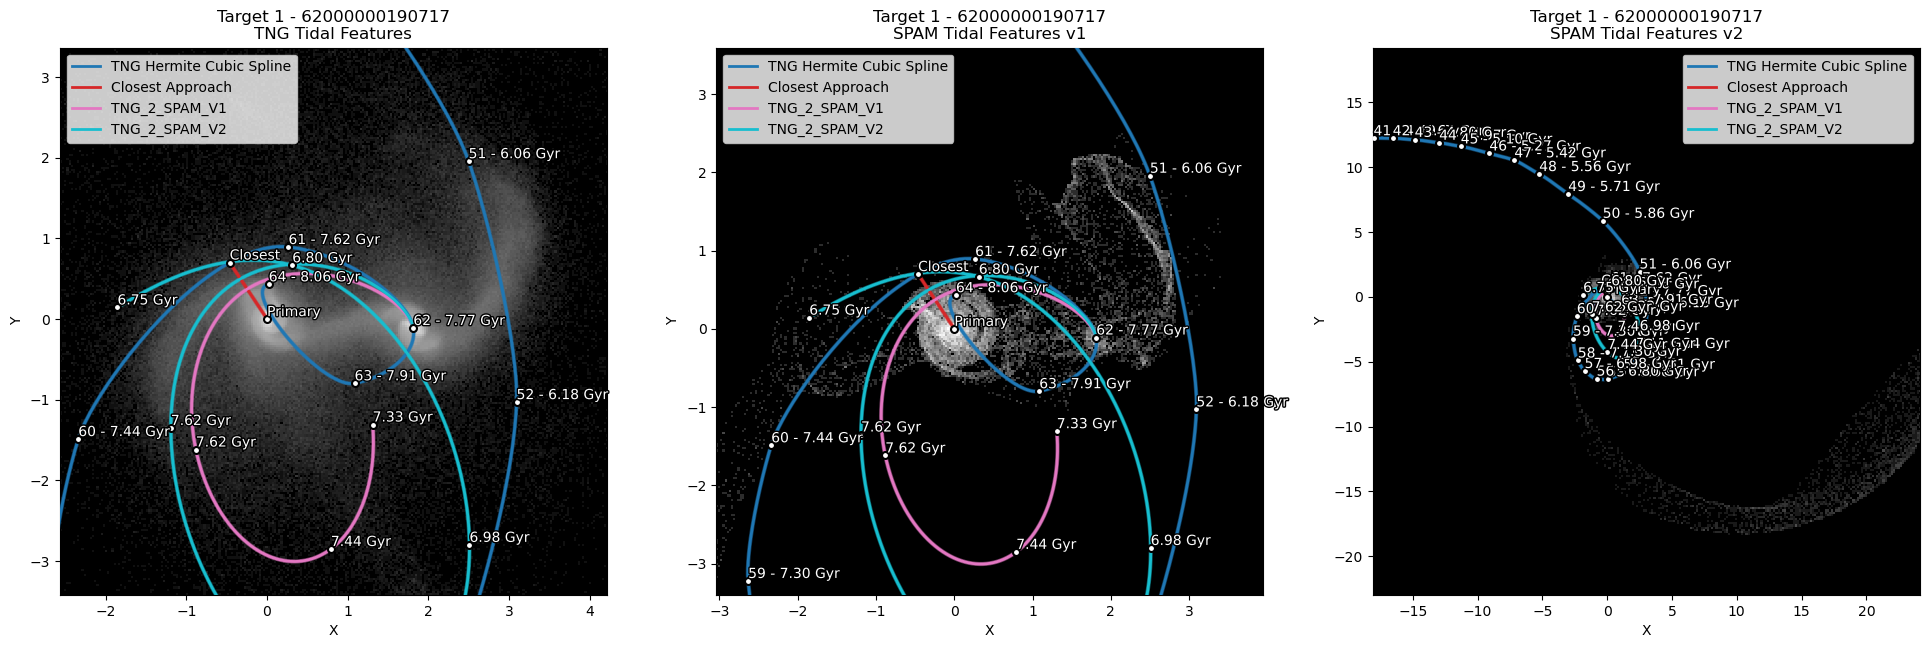

Time:2024-12-13 13:59:44,364 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run
Time:2024-12-13 13:59:44,365 - [new_simulator.basic_run_wrapper] - DEBUG - Calling custom_runs.basic_disk: [ 8.07e-01  1.61e-01 -1.37e-08 -5.00e-02 -4.33e-01 -7.31e-02  4.31e+00
  6.39e-01  5.42e-01  5.38e-01 -4.55e+01  9.19e+01  5.18e+01  1.34e+02
  5.42e-02  5.38e-02  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00]
Time:2024-12-13 13:59:57,009 - [new_simulator.basic_run_wrapper] - DEBUG - Returned Disk Particles: (20001, 6) - (20001, 6)
Time:2024-12-13 13:59:57,011 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run
Time:2024-12-13 13:59:57,013 - [new_simulator.basic_run_wrapper] - DEBUG - Calling custom_runs.basic_disk: [ 8.07e-01  1.61e-01 -1.37e-08 -5.00e-02 -4.33e-01 -7.31e-02  4.15e+00
  7.24e-01  6.30e-01  4.24e-01 -3.13e+01  7.24e+01  4.49e+01  1.10e+02
  6.30e-02  4.24e-02  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.

<Figure size 640x480 with 0 Axes>

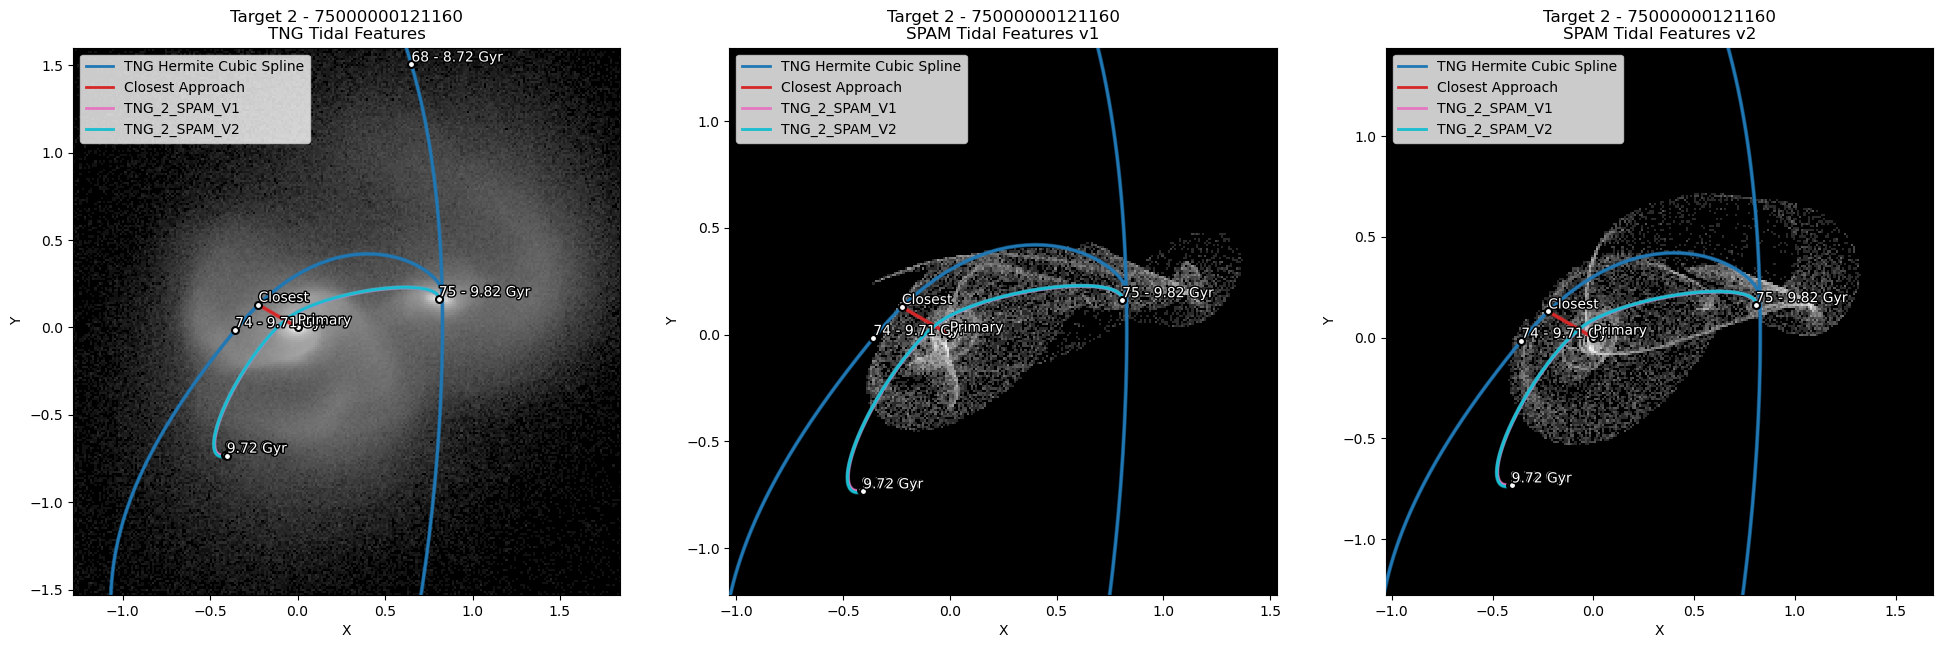

In [19]:
if buildEnv:

    # Let's have SPAM simulate some particles and see if they overlap.
    # This will take a while, so only run if needed
    overwrite = False
    n_pts = 10000
    if tng_target_1.get('spam_pts_f_v1') is None or overwrite:
        tng_target_1['spam_pts_i_v1'], tng_target_1['spam_pts_f_v1'] = sim.basic_run_wrapper( tng_target_1['spam_ar_v1'], npts1=n_pts, npts2=n_pts )
    
    if tng_target_1.get('spam_pts_f_v2') is None or overwrite:
        tng_target_1['spam_pts_i_v2'], tng_target_1['spam_pts_f_v2'] = sim.basic_run_wrapper( tng_target_1['spam_ar_v2'], npts1=n_pts, npts2=n_pts )
    
    # Print pt info
    print( f"SPAM Points: {tng_target_1['spam_pts_f_v1'].shape}" )

    # Create three side by side plots
    fig, axs = plt.subplots(1, 3, figsize=(24, 12))

    # TNG points
    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nTNG Tidal Features',
        ext_ax = axs[0]
    )

    # SPAM points v1
    xy_histogram( \
        tng_target_1['spam_pts_f_v1'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v1',
        ext_ax = axs[1]
    )

    # SPAM points v2
    xy_histogram( \
        tng_target_1['spam_pts_f_v2'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v2',
        ext_ax = axs[2]
    )

    plt.show()

    # Do the same for target 2
    if tng_target_2.get('spam_pts_f_v1') is None or overwrite:
        tng_target_2['spam_pts_i_v1'], tng_target_2['spam_pts_f_v1'] = sim.basic_run_wrapper( tng_target_2['spam_ar_v1'], npts1=n_pts, npts2=n_pts )
    
    if tng_target_2.get('spam_pts_f_v2') is None or overwrite:
        tng_target_2['spam_pts_i_v2'], tng_target_2['spam_pts_f_v2'] = sim.basic_run_wrapper( tng_target_2['spam_ar_v2'], npts1=n_pts, npts2=n_pts )
    
    # Clear previous plot
    plt.clf()

    # Create three side by side plots
    fig, axs = plt.subplots(1, 3, figsize=(24, 12))

    # TNG points
    xy_histogram( \
        tng_target_2['pts'], \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nTNG Tidal Features',
        ext_ax = axs[0]
    )

    # SPAM points v1
    xy_histogram( \
        tng_target_2['spam_pts_f_v1'], \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v1',
        ext_ax = axs[1]
    )

    # SPAM points v2
    xy_histogram( \
        tng_target_2['spam_pts_f_v2'], \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v2',
        ext_ax = axs[2]
    )

---
---

# TNG to SPAM Conversion Tidal Feature Analysis
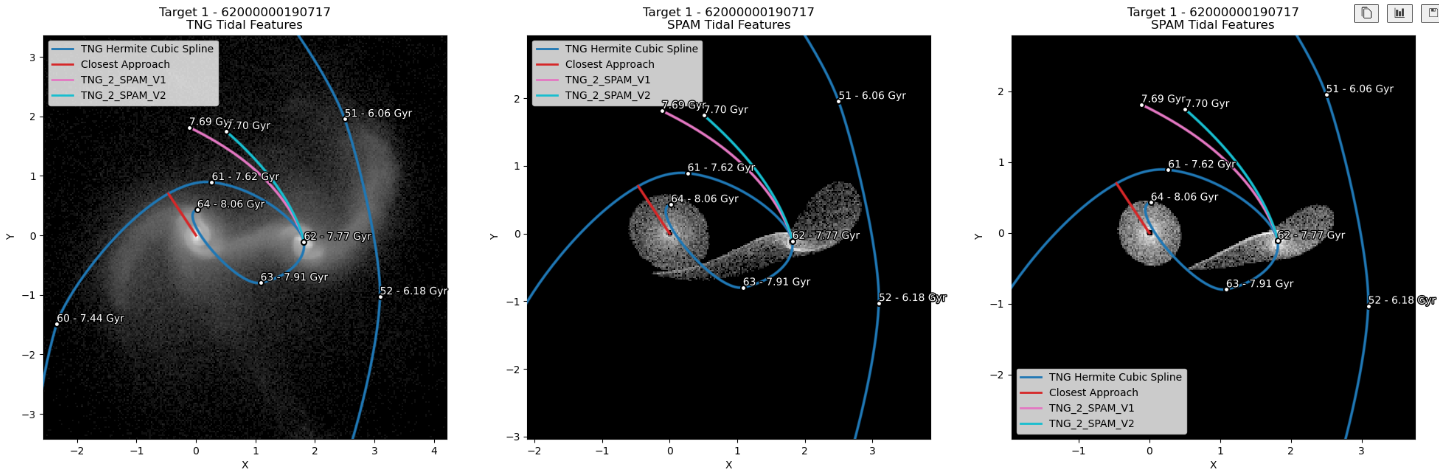

## Comparing v1 and v2
Looking at the orbits and tidal features, we can see that the version 1 and 2 functions of converting TNG target parameters into SPAM parameters do have a slight difference.  (See functions above for more details.)  Because I believe version 2 is more accurate, I will be using that for the rest of the analysis.

## Comparing TNG to SPAM
Looking at the tidal features of both, we can see that the secondary galaxy is starting to form features.  But not the first.  This could be because the radius isn't long enough however.   Let's try increasing the radius and see if that helps.

---
---

Time:2024-12-13 14:00:12,789 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run


Size List: [ 3.    5.25  7.5   9.75 12.  ]
Default Size: 2.5
0 - 3.00


Time:2024-12-13 14:02:12,825 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run


Size: 3.00 - (20001, 6)
1 - 5.25
Size: 5.25 - (20001, 6)
2 - 7.50


Time:2024-12-13 14:04:16,922 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run
Time:2024-12-13 14:06:19,380 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run
Time:2024-12-13 14:08:17,638 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run


Size: 7.50 - (20001, 6)
3 - 9.75
Size: 9.75 - (20001, 6)
4 - 12.00


Time:2024-12-13 14:10:19,332 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 14:10:19,442 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


Size: 12.00 - (20001, 6)


Time:2024-12-13 14:10:19,551 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 14:10:19,661 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 14:10:19,771 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 14:10:19,883 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


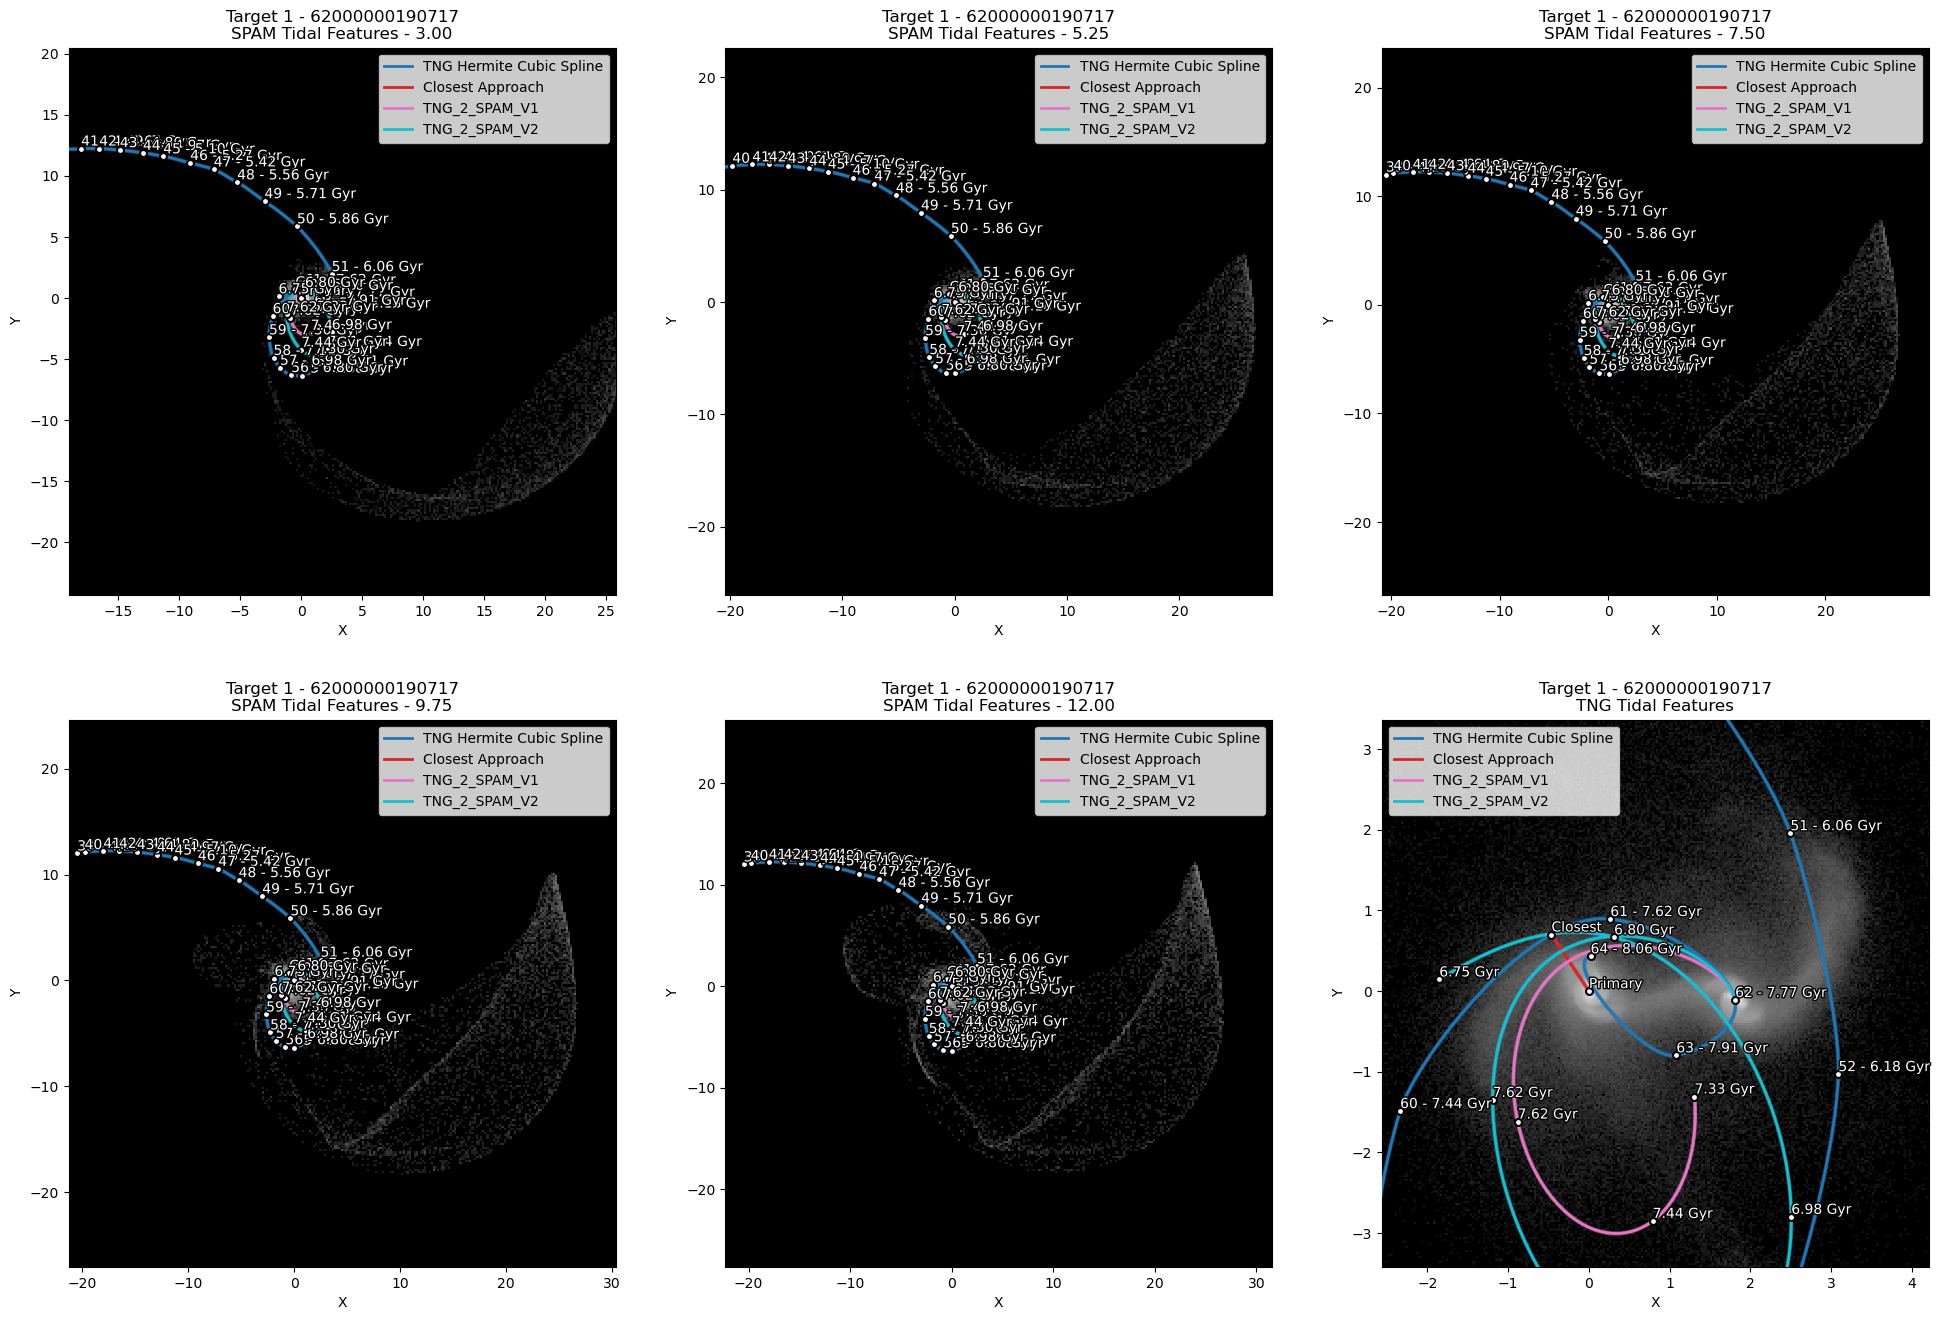

In [20]:
if buildEnv:

    logger.setLevel(logging.INFO)

    # Let's iterate over a few difference sizes of the SPAM orbits
    r_scale_list = np.linspace( 3.0, 12.0, 5 )
    print( f"Size List: {r_scale_list}" )
    print("Default Size: 2.5")

    overwrite = False
    n_pts = 10000
    if tng_target_1.get('scaled_spam_pts') is None or overwrite:
        tng_target_1['scaled_spam_pts'] = {}

    for i, r in enumerate(r_scale_list):        
        if tng_target_1['scaled_spam_pts'].get(r) is None or overwrite:

            print( f"{i} - {r:.2f}" )
            _, spam_ar = tng_target_1['gen_new_spam_arrays']( r )
            # print( f"{i} - {r:.2f} - {spam_ar}" )
            _, tng_target_1['scaled_spam_pts'][r] = sim.basic_run_wrapper( spam_ar, npts1=n_pts, npts2=n_pts )
    
        print( f"Size: {r:.2f} - {tng_target_1['scaled_spam_pts'][r].shape}" )
    
    # Create a 2x3 subplot
    fig, axs = plt.subplots(2, 3, figsize=(24, 16))


    # Iterate left to right for different sizes
    for i, r in enumerate(r_scale_list):
        xy_histogram( \
            tng_target_1['scaled_spam_pts'][r], \
            tng_target_1['plot_list'], tng_target_1['plot_labels'], \
            show_labels = True, std_dev = 3,
            annotations= tng_target_1['annotations'],
            title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features - {r:.2f}',
            ext_ax = axs[i//3,i%3]
        )

    # Lower right for TNG
    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nTNG Tidal Features',
        ext_ax = axs[-1,-1]
    )

---
---


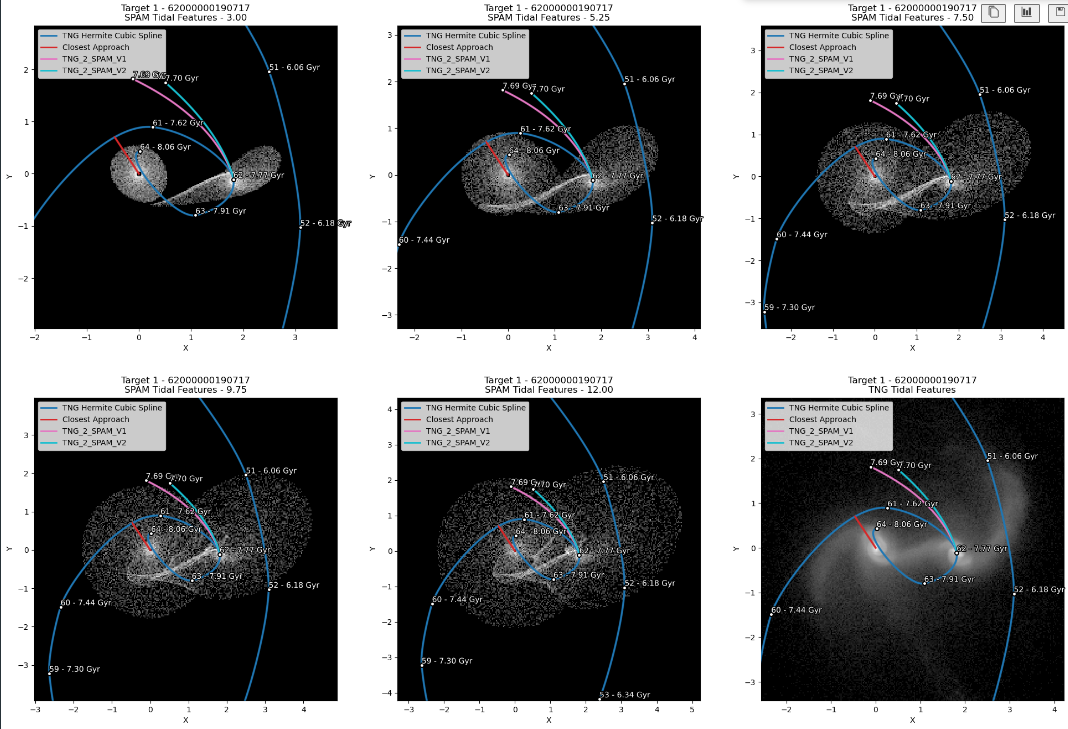

# TNG to SPAM Simulation Analysis

So increasing the radius did help, but it's fairly clear the tidal features DO NOT match up.  This is concerning, however I have an idea.  I believe it is because the orbits are off.  Based on literature of merging galaxies, the orbital parameters and galaxy orientation at the moment of closest approach have a high impact on the tidal features.  Thus, we need to try and adjust the orbit until it overlaps the tng orbit.   However, we do NOT want to change the TNG Spam parameters because they are our control and should be what SPAM is able to recreate.  

(With exception of the radius.  The radius is based on the half mass radius of the TNG galaxy, and the SPAM radius is for the entire disk of stars.  While they are likely a scale of one another, I do not know that scale yet so we will need to manually adjust the radius to match tidal features later.) 

It just so happens that SPAM simulation itself has some parameters that are hardcoded.  For instance, it have a variable for affecting how strong the dynamical friction is. This was hardcoded during Galaxy Zoo: Mergers, but I've gone ahead and made this an adjustable variable in SPAM.  This will most certainly affect the orbit given it actively slows down the secondary galaxy. 

Another set of variables I can change is the "unit disk galaxy" SPAM uses.  Based on observations of the Milky Way, SPAM hardcodes the size ratio and mass ratio between the galactic bulge, disk and dark matter halo.  However, more recent literature indicates the dark matter halo could be much larger than previously thought.  Thus, I went ahead and made these variables adjustable as well.  Given the two galaxies literally traveling through each others dark matter halos, this could have a significant impact the orbit and tidal features.  

DISCLAIMER:  While I am able to adjust the unit galaxy within SPAM, that single unit galaxy is used for both galaxies, scaled up and down according to the models parameters fed into SPAM.  As of right now, I have not attempted to create two unit galaxies that can be applied seperely.  If the two galaxies have drastically different scale ratios between their compoenents, is will make SPAM less likely to accurately simulate the past orbit and tidal features. 

---
---

Time:2024-12-13 14:10:26,749 - [new_simulator.orbit_run_wrapper] - INFO - Running SPAM Simulation - Orbit Run
Time:2024-12-13 14:10:31,195 - [new_simulator.orbit_run_wrapper] - INFO - Running SPAM Simulation - Orbit Run
Time:2024-12-13 14:10:34,799 - [new_simulator.basic_run_wrapper] - INFO - Running SPAM Simulation - Basic Run
Time:2024-12-13 14:12:20,367 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2024-12-13 14:12:20,711 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


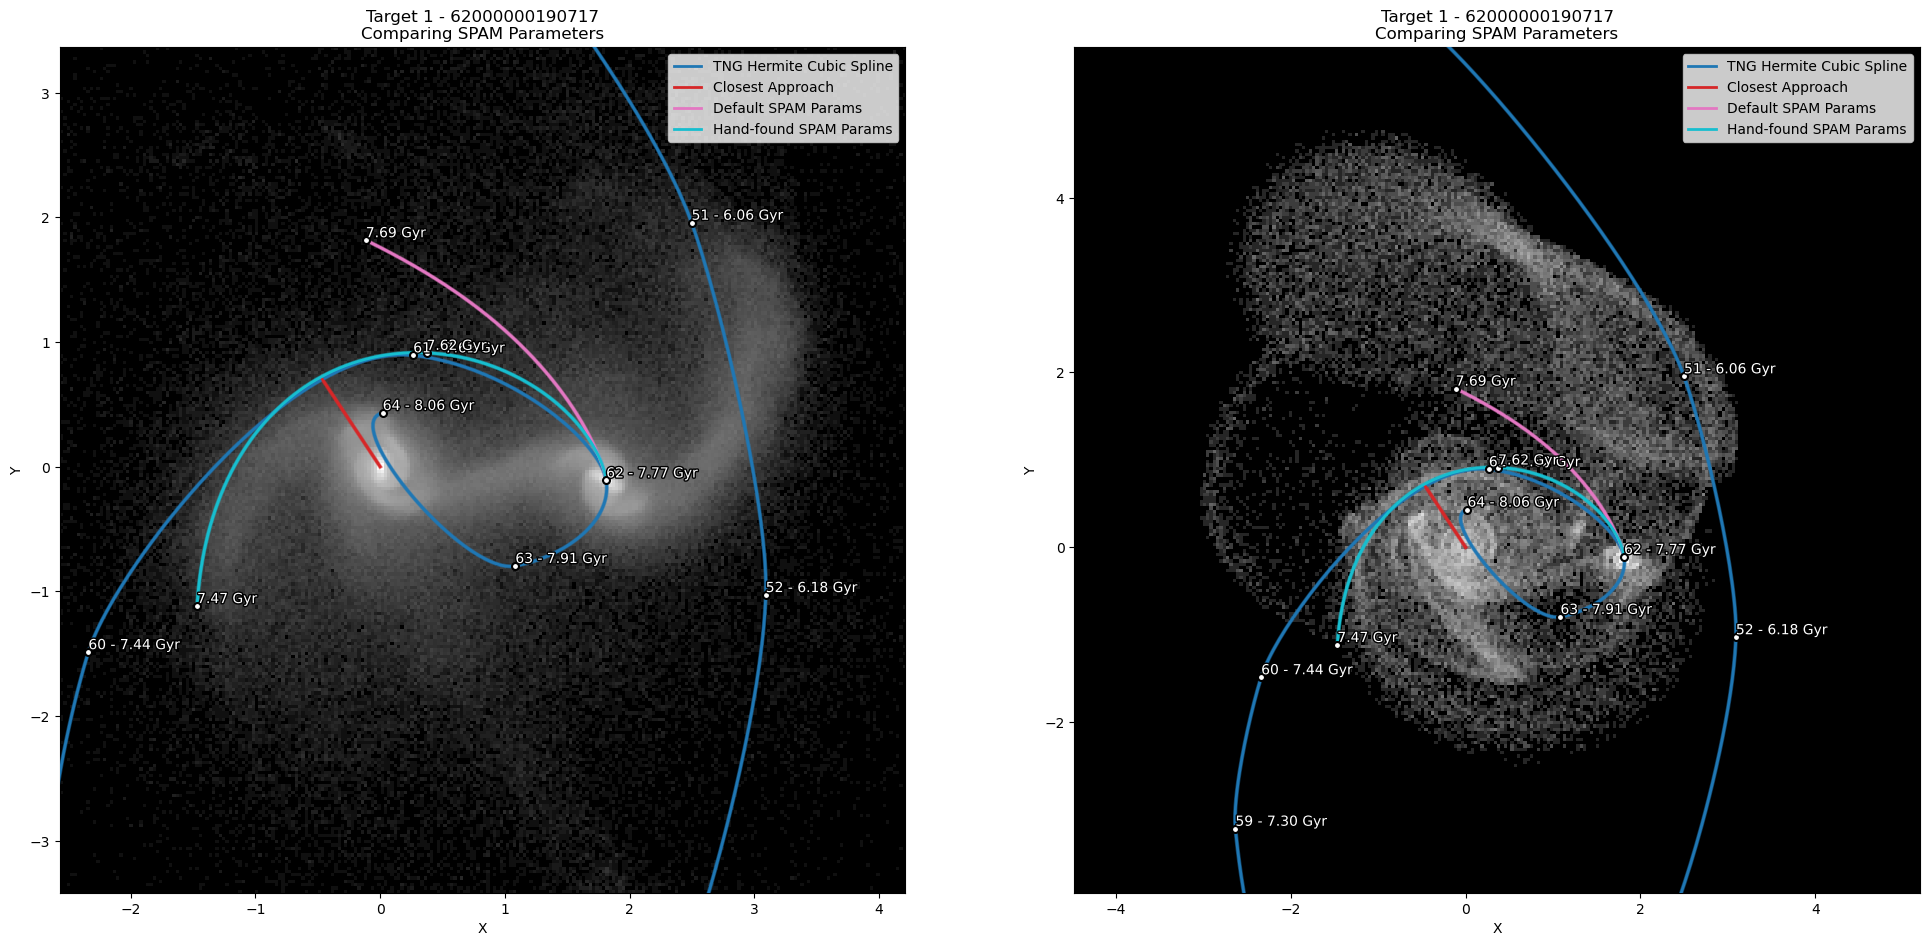

In [21]:
if buildEnv:

    logger.setLevel(logging.INFO)
    
    # Empty items default to SPAM Default
    spam_param_default = { 'label':"Default SPAM Params" }

    # This is a hand discovered SPAM parameter set that appears to be a good match
    spam_param_hand = {
        'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
        'label': 'Hand-found SPAM Params'
    }

    # Let's adjust the SPAM parameters to see if we can get a better match
    overwrite = True
    
    if overwrite:
        tng_target_1 = tng_target_1['reset_plot_info']()
        tng_target_1['spam_orbit_default'] = None
        tng_target_1['spam_orbit_hand'] = None
        tng_target_1['spam_pts_hand'] = None

    if tng_target_1.get('spam_orbit_default') is None:
        tng_target_1['spam_orbit_default'] = sim.orbit_run_wrapper( tng_target_1['spam_ar_v1'], current_time=tng_target_1['current_time'], spam_setup_params=spam_param_default )
        _  = add_spam_orbit_info( tng_target_1['spam_orbit_default'], tng_target_1, spam_param_default['label'], True, False )

    if tng_target_1.get('spam_orbit_hand') is None:
        tng_target_1['spam_ar_hand'] = tng_target_1['gen_new_spam_arrays']( 9.0 )[0]
        tng_target_1['spam_orbit_hand'] = sim.orbit_run_wrapper( tng_target_1['spam_ar_hand'], current_time=tng_target_1['current_time'], spam_setup_params=spam_param_hand )
        _ = add_spam_orbit_info( tng_target_1['spam_orbit_hand'], tng_target_1, spam_param_hand['label'], True, False )
    
    if tng_target_1.get('spam_pts_hand') is None:
        _, tng_target_1['spam_pts_hand'] = sim.basic_run_wrapper( tng_target_1['spam_ar_hand'], npts1=20000, npts2=40000, spam_setup_params=spam_param_hand, heat1=0.1, heat2=0.1 )
    
    # Let's create side by side plots
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))
    
    # Let's plot the new orbit
    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nComparing SPAM Parameters',
        # figsize=(12,12),
        ext_ax = axs[0],
    )

    # Let's plot the new particles
    xy_histogram( \
        tng_target_1['spam_pts_hand'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nComparing SPAM Parameters',
        ext_ax = axs[1],
    )
        

---
---
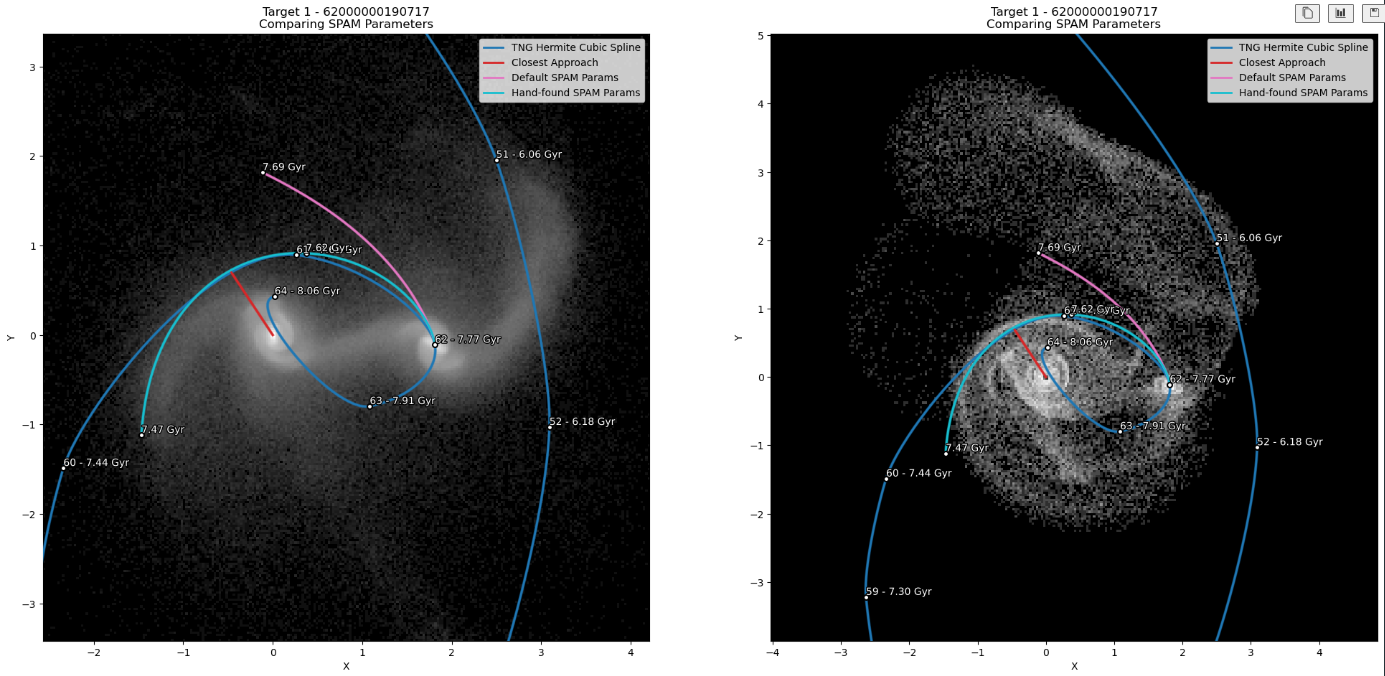

# Wonderful Success!

As suspected, by adjusting the SPAM parameters to get the orbits to overlaps, the tidal features are remarkably close!  This is a huge success and shows that SPAM can accurately simulate the tidal features of colliding galaxies.  Do note, these parameters were found by trial and error via manaul tweaking.  If we develope a fitness function to score the overlap of the orbits, we may be able to automate this process and achieve greater accuracy.

---
---
# OKAY MATTHEW, END SCRIPT

So I HAD an entire 2nd half to this notebook that's all about creating orbit fitness functions and doing a gridsearch of the SPAM parameters, then thinking of optimization programs (And fixings bugs after hours of garbage compuations).  But the notebook got FAR too long (1900 ish lines here).  And I started getting overwhelmed trying to scroll up and down, making edits, and rerunning everything; so I'm going to end this here.  I am making a new script for tuning the SPAM Simulation Parameters within the Simulation Directory.

In [22]:
def orbit_weighted_score_function( path, spam_orbit ):

    LOGGER.info("Calculating Weighted Error...")

    n_spam = len(spam_orbit)  # length of spam run
    spam_times = spam_orbit[:,-1]  # Times in spam run
    spam_dt = abs((spam_times[-1] - spam_times[0]) / (n_spam - 1))  # average time step in spam run

    # Verify spam run went back to the same time as the TNG run
    LOGGER.debug("SPAM Orbit: %s", spam_orbit.shape)
    LOGGER.debug( f"SPAM Time: {spam_times[0]:.2f} - {spam_times[-1]:.2f} Gyr")

    if spam_times[0] > path['past_time']:
        LOGGER.debug("SPAM run started after the past time")

        # Get number of dts needed to fill the gap between spam_time[0] and path['past_time']
        n_more = int( np.ceil( (spam_times[0] - path['past_time']) / spam_dt ) )

        # Create new times array that goes back to the past time
        new_times = np.linspace( path['past_time'], spam_times[0], n_more )
        times = np.concatenate( (new_times, spam_times) )

        LOGGER.debug( f"Adding {n_more} more time steps to SPAM run")
        LOGGER.debug( f"New Times: {new_times.shape}")
        LOGGER.debug( f"{new_times[:3]} - {new_times[-3:]}")
        LOGGER.debug( f"Compare Times: {times.shape}")
        LOGGER.debug( f"{times[:3]} - {times[-3:]}")
        
    # Else use the spam run times
    else:
        n_more = 0
        times = spam_times

    n = len(times)  # length of new times array
    LOGGER.debug( f"Times: {times.shape}")

    # Create tng_orbit from spline and times
    tng_orbit = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_nat_func']] for t in times ])
    LOGGER.debug( f"Path TNG: {tng_orbit.shape}")
    
    # Create weights from the path['weight_func']
    weights = path['weight_func']( times )
    LOGGER.debug( f"Weights: {weights.shape}")
    LOGGER.debug( f"Weight Range: {weights.min()} - {weights.max()}")

    # Calcule normalization factor for weights
    total_weight = np.sum(weights)
    LOGGER.debug( f"Total Weight: {total_weight}")

    # Compute errors
    errors = np.zeros(n)

    for i in range(n):

        # If i is less than n_more, use the first simulated position
        if i < n_more:
            # Directly compare positions for same time step
            e = np.linalg.norm(spam_orbit[0,0:3] - tng_orbit[i,0:3]) ** 2
        else:
            # Use first simulated position
            spam_idx = i - n_more
            e = np.linalg.norm(spam_orbit[spam_idx,0:3] - tng_orbit[i,0:3]) ** 2
        errors[i] = e

    LOGGER.debug( f"Errors: {errors.shape}")

    # Compute weighted error
    E = np.sum(weights * errors)
    E_normalized = E / total_weight

    LOGGER.debug( f"Weighted Error: {E_normalized}")

    return E_normalized



if buildEnv and False:

    LOGGER.setLevel(logging.INFO)
    
    # Let's verify the score function does as I expect
    hand_score = orbit_weighted_score_function( path1, hand_orbit )

    # LOGGER.setLevel(logging.INFO)

    default_score = orbit_weighted_score_function( path1, default_orbit )

    print("Hand Score: ", hand_score)
    print("Default Score: ", default_score)

    plot_list = path1['plot_list'].copy()
    plot_labels = path1['plot_labels'].copy()
    plot_annotations = path1['annotate_data'].copy()

    plot_list.append( hand_orbit )
    plot_labels.append( f'Hand - {hand_score}' )
    plot_annotations = add_annotate_times( plot_annotations, hand_orbit, path['times_su'] )

    plot_list.append( default_orbit )
    plot_labels.append( f'Default - {default_score}' )
    plot_annotations = add_annotate_times( plot_annotations, default_orbit, path['times_su'] )

    xy_histogram( \
        pts1, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 5,
        annotate_data= plot_annotations,
        title = 'TNG SPAM Comparison - 1',
        figsize=(12,12),
    )

In [23]:
if buildEnv:

    # I want to see how the score changes if I shorten the hand_orbit
    # one of the issues was the program overscored short orbits

    LOGGER.setLevel(logging.WARNING)

    loop_list = [ ( 'Hand v1', hand_orbit)]
    loop_list.append( ( 'Hand v2', hand_orbit_v2) )
    loop_list.append( ( 'Default v1', default_orbit) )
    loop_list.append( ( 'Default v2', default_orbit_v2) )

    for label, orbit in loop_list:
        n = len(orbit)
        scores = []
        lengths = []
        for i in range(0, n, 100):
            print(f"Scoring orbit length: {i} / {n}", end='\r')
            tmp_score = orbit_weighted_score_function( path1, orbit[i:] )

            # If i == 0, this is default score
            if i == 0:
                plt.axhline( tmp_score, color='k', linestyle=':' )
            scores.append( tmp_score )
            lengths.append( i )
        
        plt.plot( lengths, scores, label=label )


    plt.title("Score If you Shorten Orbit")
    plt.legend()

    plt.xlabel("N Points Removed from Orbit")
    plt.ylabel("Weighted Error")

    # Scale y axis
    # plt.yscale('log')

NameError: name 'hand_orbit' is not defined

Time:2024-12-02 16:17:38,515 - [381519902.__init__] - INFO - Setting up Orbit Generator...


Time:2024-12-02 16:17:38,515 - [381519902.__init__] - INFO - Setting up Orbit Generator...


Time:2024-12-02 16:17:39,330 - [1314880471.spam_orbit_wrapper_squared] - INFO - Running SPAM simulator...


Time:2024-12-02 16:17:39,330 - [1314880471.spam_orbit_wrapper_squared] - INFO - Running SPAM simulator...


Time:2024-12-02 16:17:44,996 - [1314880471.spam_orbit_wrapper_squared] - INFO - Running SPAM simulator...


...

Time:2024-12-02 16:17:51,386 - [1314880471.spam_orbit_wrapper_squared] - INFO - Running SPAM simulator...


Time:2024-12-02 16:17:55,030 - [2390029634.orbit_weighted_score_function] - INFO - Calculating Weighted Error...


Time:2024-12-02 16:17:55,030 - [2390029634.orbit_weighted_score_function] - INFO - Calculating Weighted Error...


Time:2024-12-02 16:17:55,292 - [295682812.xy_histogram] - INFO - Plotting 2D Histogram...


Time:2024-12-02 16:17:55,292 - [295682812.xy_histogram] - INFO - Plotting 2D Histogram...


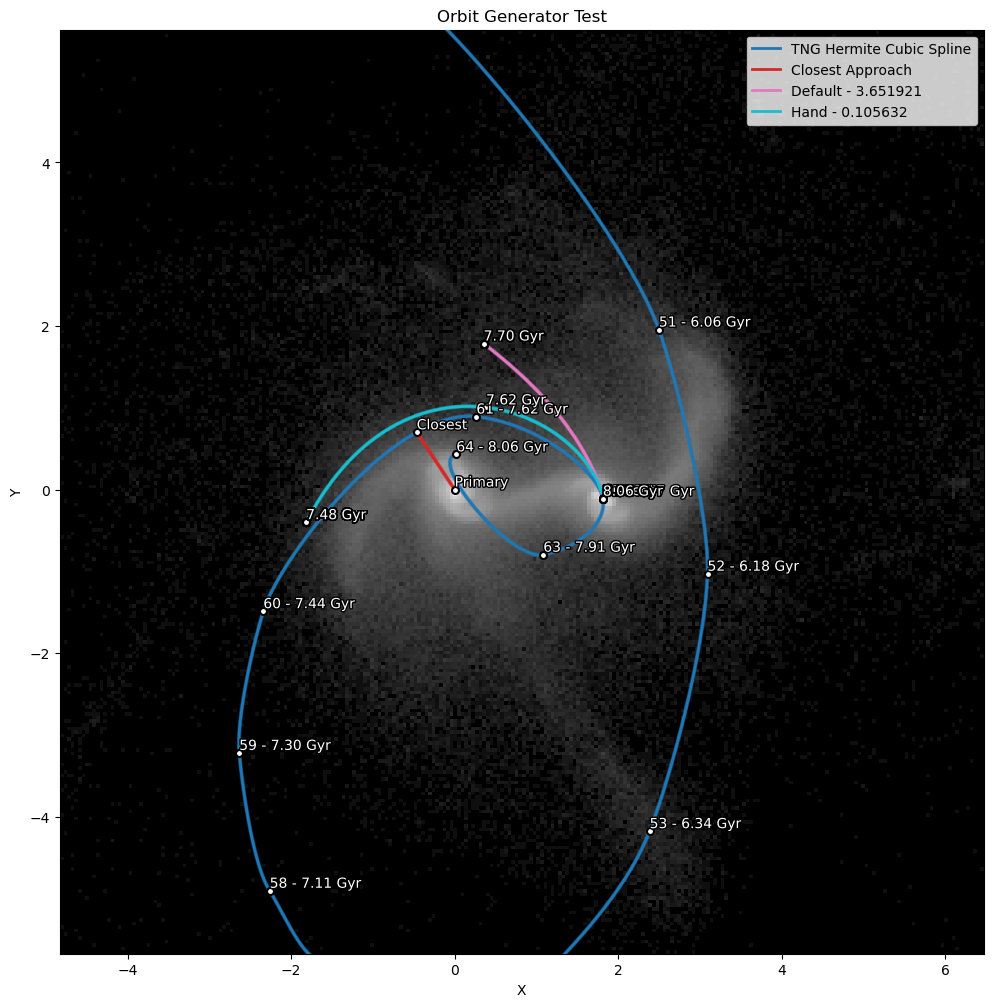

In [ ]:
class orbit_generator_class:

    def __init__(self, p_id, x_dict, save_dir = None, save_orbit = False):

        LOGGER.info("Setting up Orbit Generator...")
        self.p_id = p_id

        # Get MPI rank of myself
        rank = MPI.COMM_WORLD.Get_rank()

        # Save x_dict to keep input names for later function call
        if x_dict is not None:
            self.x_dict = x_dict
        else:
            LOGGER.error("x_dict cannot be None")
            raise ValueError("x_dict cannot be None")
        
        # If save_orbit is True, ensure there's a save dir
        if save_orbit and save_dir is None:
            LOGGER.error("save_dir must be set if save_orbit is True")
            raise ValueError("save_dir must be set if save_orbit is True")

        # If saving files, ensure the directory exists
        self.save_dir = None
        self.c = 0
        if save_dir is not None:
            self.save_dir = save_dir

            # create dir if needed
            if not os.path.exists( self.save_dir ):
                os.makedirs( self.save_dir )

            # Creat a log file that should be unique to me
            self.log_file = os.path.join( self.save_dir, f'{rank}.log' )

            # Create generic zip orbit path for later use
            self.orbit_loc = os.path.join( self.save_dir, f'{rank}_orbit_%d_%d.npz' )

            self.save_orbit = save_orbit

        # Create dataframe to hold info
        self.log_df = pd.DataFrame()

        # Setup default variables
        self.t_row, self.t_df, self.path = get_tng_target_orbit( self.p_id )

        # Create SPAM arrays for the target
        # print("Past Snap: ", self.path['before_closest_approach_snap'])
        self.tng_ar_1 = standardize_tng_parameters_v1( self.t_row )
        self.tng_ar_2 = standardize_tng_parameters_v2( self.t_df, self.t_row['snap'], self.path['before_closest_approach_snap'] )

        self.spam_ar_1 = convert_units_tng_to_spam( self.tng_ar_1 )
        self.spam_ar_2 = convert_units_tng_to_spam( self.tng_ar_2 )

        # print( f"SPAM AR 1: {self.spam_ar_1}")
        # print( f"SPAM AR 2: {self.spam_ar_2}")

    def create_orbit(self, in_setup_ar = None, in_setup_dict = None):

        if in_setup_dict is None and in_setup_ar is None:
            LOGGER.error("in_setup_dict or in_setup_ar must be set")
            raise ValueError("in_setup_dict or in_setup_ar must be set")

        if in_setup_dict is None:
            in_setup_dict = {}
            for i, x in enumerate(self.x_dict):
                in_setup_dict[x] = in_setup_ar[i]

        spam_orbit = spam_orbit_wrapper_squared( self.spam_ar_2, spam_setup_var=in_setup_dict, current_time=self.t_row['times_su'] )
        return spam_orbit

    def create_orbit_log_wrapper(self, in_setup_ar):

        # Loop through x_range and save name to in_ar variables
        in_setup_dict = {}
        for i, x in enumerate(self.x_dict):
            in_setup_dict[x] = in_setup_ar[i]

        LOGGER.debug("Running SPAM Simulation... %s", str(in_setup_dict))
        # spam_orbit_1 = spam_orbit_wrapper_squared( self.spam_ar_1, spam_setup_var=in_var, current_time=self.t_row['times_su'] )
        # LOGGER.debug( f"SPAM Orbit Shape: {spam_orbit_1.shape}" )
        spam_orbit_2 = spam_orbit_wrapper_squared( self.spam_ar_2, spam_setup_var=in_setup_dict, current_time=self.t_row['times_su'] )
        LOGGER.debug( f"SPAM Orbit Shape: {spam_orbit_2.shape}" )

        # Copy in_var and add keys and values to it
        in_var['p_id'] = self.p_id
        # in_var['orbit_n_1'] = spam_orbit_1.shape[0]
        in_var['orbit_n_2'] = spam_orbit_2.shape[0]
        in_var['c'] = self.c

        # Save orbit to a file
        if self.save_dir is not None:
            # tmp_save_loc_1 = self.orbit_loc % (self.c, 0)
            tmp_save_loc_2 = self.orbit_loc % (self.c, 1)
            
            # in_var['orbit_loc_1'] = tmp_save_loc_1
            in_var['orbit_loc_2'] = tmp_save_loc_2

            # np.savez( tmp_save_loc_1, spam_orbit_1 )
            np.savez( tmp_save_loc_2, spam_orbit_2 )

            LOGGER.debug( f"Saved Orbit to: {tmp_save_loc_1}" )

        # Add dict to dataframe
        self.log_df = pd.concat([self.log_df, pd.DataFrame([in_var])], ignore_index=True)

        # Save the dataframe
        if self.save_dir is not None: self.log_df.to_csv( self.log_file, index=False )
        
        self.c += 1 

        return spam_orbit_2
    

    def create_score_log_wrapper(self, in_setup_ar = None, in_setup_dict = None):

        if in_setup_dict is None and in_setup_ar is None:
            LOGGER.error("in_setup_dict or in_setup_ar must be set")
            raise ValueError("in_setup_dict or in_setup_ar must be set")
        
        if in_setup_dict is None:
            in_setup_dict = {}
            for i, x in enumerate(self.x_dict):
                in_setup_dict[x] = in_setup_ar[i]
        
        LOGGER.debug("Running SPAM Simulation... %s", str(in_setup_dict))
        spam_orbit = spam_orbit_wrapper_squared( self.spam_ar_2, spam_setup_var=in_setup_dict, current_time=self.t_row['times_su'] )
        LOGGER.debug( f"SPAM Orbit Shape: {spam_orbit.shape}" )
        
        # Get score for spam_orbit
        score = orbit_weighted_score_function( self.path, spam_orbit )

        # Add info to log
        log_dict = in_setup_dict.copy()
        log_dict['p_id'] = self.p_id
        log_dict['score'] = score
        log_dict['c'] = self.c
        log_dict['orbit_n'] = spam_orbit.shape[0]

        # Save orbit to a file
        if self.save_dir is not None and self.save_orbit:
            tmp_save_loc = self.orbit_loc % (self.c, 1)
            log_dict['orbit_loc'] = tmp_save_loc
            np.savez( tmp_save_loc, spam_orbit )
            LOGGER.debug( f"Saved Orbit to: {tmp_save_loc}" )
        else:
            LOGGER.debug("Not saving orbit")
        # Add dict to dataframe
        self.log_df = pd.concat([self.log_df, pd.DataFrame([log_dict])], ignore_index=True)

        # Save the dataframe
        if self.save_dir is not None: self.log_df.to_csv( self.log_file, index=False )

        # increment counter
        self.c += 1

        return score

if buildEnv:
    
    # Set up grid search variables and bounds
    test_dict = {
        'lnl': {'bounds':[0.001, 1], 'prior': 'log-uniform'},
        'r_scale': {'bounds':[1, 60], 'prior': 'uniform'},
        'mhalo': {'bounds':[1, 40], 'prior': 'uniform'}
    }

    default = [0.1, 10.0, 5.8]
    hand = [0.007, 20.0, 5.8]

    LOGGER.setLevel(logging.INFO)

    # Create a generator
    gen = orbit_generator_class( p1, test_dict )

    tmp_orbit_d = gen.create_orbit( default )
    tmp_score_d = gen.create_score_log_wrapper( default )

    tmp_orbit_h = gen.create_orbit( hand )
    tmp_score_h = gen.create_score_log_wrapper( hand )

    # plot these paths
    plot_list = path1['plot_list'].copy()
    plot_labels = path1['plot_labels'].copy()
    plot_annotations = path1['annotate_data'].copy()

    plot_list.append( tmp_1 )
    plot_labels.append( 'Default - %f' % tmp_score_d )
    plot_annotations = add_annotate_times( plot_annotations, tmp_1, path['times_su'] )

    plot_list.append( tmp_2 )
    plot_labels.append( 'Hand - %f' % tmp_score_h )
    plot_annotations = add_annotate_times( plot_annotations, tmp_2, path['times_su'] )

    xy_histogram( \
        pts1, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 5,
        annotate_data= plot_annotations,
        title = 'Orbit Generator Test',
        figsize=(12,12),
    )


In [ ]:

def gen_orbit_gridsearch( args, x_dict = None ):

    LOGGER.info("Running Orbit Gridsearch Test...")

    # Get important parameters
    t_id = args.target_id
    time_in_sec = int(args.input)
    output_dir = args.output

    # Set up grid search variables and bounds
    if x_dict is None:
        x_dict = {
            'lnl': {'bounds':[0.001, 1], 'prior': 'log-uniform'},
            'rscale': {'bounds':[1, 60], 'prior': 'uniform'},
            'mhalo': {'bounds':[1, 40], 'prior': 'uniform'}
        }

    # prep black box
    gen = orbit_generator_class( t_id, x_dict=x_dict, save_dir = output_dir, save_orbit=True )

    # Setup MPI for parallel processing
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()
    size = comm.Get_size()

    # Setup workers to be on standby
    if rank != 0:
        worker = om.Optimization_Manager( gen.create_score_log_wrapper, x_dict )
    
    # Setup master to run the optimization
    elif rank == 0:
        manager = om.Optimization_Manager( gen.create_score_log_wrapper, x_dict )
        results = manager.initial_exploration( time_cutoff_sec= time_in_sec )

        print("FINAL results: ", len(results)) 
        print(results)   

        del manager

    # End the MPI process

# Already completed
if buildEnv and True:
    cmdLine = 'python3 /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/convert_tng_to_spam.py'
    cmdLine += ' --function gen_orbit_gridsearch'
    cmdLine += ' -id 62000000190717'
    cmdLine += ' --input 10'
    cmdLine += ' --output /home/mbo2d/galStuff/data/orbit_gridsearch_5_test/'

    # Add mpiexec to the front of the command

    print( f"mpiexec -n 4 {cmdLine}" )
    tmp_parser = gu.ArgHandler()
    build_arg = tmp_parser.parse_args_from_string(cmdLine)
    test_x = {
        'lnl': {'bounds':[0.001, 1], 'prior': 'log-uniform'},
    }

    LOGGER.setLevel( logging.INFO )

    # gen_orbit_gridsearch( build_arg, x_dict = test_x )

    # Save cmdline in a script 
    test_script_loc = '/home/mbo2d/galStuff/cluster/batch_files/test_gridsearch.sh'
    with open(test_script_loc, 'w') as f:
        f.write( cmdLine )

if script_args.function == 'gen_orbit_gridsearch':
    gen_orbit_gridsearch( script_args, )

mpiexec -n 4 python3 /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/convert_tng_to_spam.py --function gen_orbit_gridsearch -id 62000000190717 --input 10 --output /home/mbo2d/galStuff/data/orbit_gridsearch_5_test/


In [ ]:
import glob
# Let's load all the orbits and verify they're behaving as expected
if buildEnv:
    orbit_dir = '/home/mbo2d/galStuff/data/orbit_gridsearch_5_test/'
    
    # First, load and combine all the log files
    log_files = glob.glob( os.path.join(orbit_dir, '*.log') )
    log_df = pd.DataFrame()
    for f in log_files:
        tmp_df = pd.read_csv(f)
        log_df = pd.concat([log_df, tmp_df], ignore_index=True)
    
    print( f'Logs: {log_df.shape}' )

    # Print ranges of lnl, r_scale, and mhalo
    print( f"lnl: {log_df['lnl'].min()} - {log_df['lnl'].max()}")
    print( f"r_scale: {log_df['rscale'].min()} - {log_df['rscale'].max()}")
    print( f"mhalo: {log_df['mhalo'].min()} - {log_df['mhalo'].max()}")
    
    # Second load all the orbits
    orbit_files = glob.glob( os.path.join(orbit_dir, '*.npz') )
    orbit_list = []
    for f in orbit_files:
        tmp_orbit = np.load(f)
        orbit_list.append( tmp_orbit['arr_0'] )
    
    print( 'N Orbits %d' % len(orbit_list) )

    # Load them all and plot them
    
    plot_list = path1['plot_list'].copy()
    plot_labels = path1['plot_labels'].copy()
    plot_annotations = path1['annotate_data'].copy()

    for i, orbit in enumerate(orbit_list):
        plot_list.append( orbit )
        plot_labels.append( f'Orbit {i}' )
        plot_annotations = add_annotate_times( plot_annotations, orbit, path['times_su'] )
    
    xy_histogram( \
        pts1, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 5,
        annotate_data= plot_annotations,
        title = 'Orbit Generator Test',
        figsize=(12,12),
    )


Logs: (1002, 8)
lnl: 0.001 - 1.0
r_scale: 1.0 - 60.0
mhalo: 1.0 - 40.0
N Orbits 1002


Time:2024-12-02 16:43:49,669 - [295682812.xy_histogram] - INFO - Plotting 2D Histogram...


Time:2024-12-02 16:43:49,669 - [295682812.xy_histogram] - INFO - Plotting 2D Histogram...


KeyboardInterrupt: 

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
if buildEnv and False:

    # okay, create a bunch of scripts to send to my cluster
    run_dir = '/home/mbo2d/galStuff/cluster/batch_files/'
    baseCMD = 'python3 /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/convert_tng_to_spam.py'
    baseCMD += ' --function gen_orbit_gridsearch'
    baseCMD += ' -id %s'
    baseCMD += ' --output /home/mbo2d/galStuff/data/orbit_gridsearch/%s/'
    baseCMD += ' --input %d'

    # Loop through all rows that have moi_4_rating >= 3
    good_targets = tng_targets[tng_targets['moi_4_rating'] >= 4]

    # sort so highest is first
    good_targets = good_targets.sort_values(by='moi_4_rating', ascending=False)

    # Create batch file
    file_name = 'gridsearch_cmds_4.sh'
    f = open(f'{run_dir}/{file_name}', 'w')

    # Create test batch file too
    test_file_name = 'gridsearch_cmds_4_test.sh'
    f_test = open(f'{run_dir}/{test_file_name}', 'w')

    # exe_time 
    n_hr = 0.25
    exe_time = n_hr * 60*60 # an hour

    for idx, row in good_targets.iterrows():
        t_id = row['p_SubhaloIDRaw']

        cmdLine = baseCMD % (t_id, t_id, exe_time)
        build_arg = PARSER.parse_args(cmdLine.split()[2:]) # Skip the first two arguments
        
        # Write to file
        f.write( cmdLine + '\n')

        # if matches p1 or p2, save as test
        if t_id == p1 or t_id == p2:
            print("Test: ", t_id)
            testCMD = cmdLine + ' --log-level DEBUG'
            f_test.write( testCMD + '\n')
    
    f.close()
    f_test.close()

    # print size of good_targets
    print( f"Good Targets: {len(good_targets)}" )

In [ ]:
if buildEnv:
    test_orbit_dir = '/home/mbo2d/galStuff/data/orbit_gridsearch_5_test/'

    # Get all files in the directory
    all_files = os.listdir( test_orbit_dir )

    # Loop through log files and load them
    all_dfs = []
    for f in all_files:
        if f.endswith('.log'):
            all_dfs.append( pd.read_csv( os.path.join( test_orbit_dir, f ) ) )

    # Concatenate all dataframes
    log_df = pd.concat( all_dfs, ignore_index=True )

    # print length
    print( f"Total Orbits: {len(log_df)}" )

    # Print head
    print( log_df.head() )

    # Add cutoff for orbits that are too long
    # cutoff = 4000
    # log_df = log_df[log_df['orbit_n_1'] < cutoff]

    # # Remove those above 
    n_values_1 = log_df['orbit_n_1'].values
    n_values_2 = log_df['orbit_n_2'].values

    # Get unique values in each 
    unique_n_1 = np.unique( n_values_1 )
    unique_n_2 = np.unique( n_values_2 )

    print( f"Unique N 1: {unique_n_1}" )
    print( f"Unique N 2: {unique_n_2}" )

    # Let's create two subplots on top of each other
    fig, axs = plt.subplots(2, 1, figsize=(12, 12))
    
    # Plot the histogram of the orbit_n values
    axs[0].hist( n_values_1, bins=100, color='b', alpha=0.7 )
    axs[0].set_title("Orbit N Values - TNG_2_SPAM v1")

    axs[1].hist( n_values_2, bins=100, color='r', alpha=0.7 )
    axs[1].set_title("Orbit N Values - TNG_2_SPAM v2")

    # # Grab the rows with the highest and lowest orbit_n values
    # print( log_df[log_df['orbit_n'] == np.max(log_df['orbit_n'].values)] )
    # print( log_df[log_df['orbit_n'] == np.min(log_df['orbit_n'].values)] )

    # # lOG SCALE
    plt.show()

Total Orbits: 965
        lnl     rscale      mhalo            p_id     score  c  orbit_n  \
0  0.005623  30.500000   1.000000  62000000190717  4.229021  0     1654   
1  1.000000   1.000000  30.250000  62000000190717  3.795426  1      302   
2  0.001000  60.000000  30.250000  62000000190717  3.075456  2     5002   
3  1.000000   1.000000  20.500000  62000000190717  4.556050  3      265   
4  0.432876  54.636364  36.454545  62000000190717  4.079769  4      627   

                                           orbit_loc  
0  /home/mbo2d/galStuff/data/orbit_gridsearch_5_t...  
1  /home/mbo2d/galStuff/data/orbit_gridsearch_5_t...  
2  /home/mbo2d/galStuff/data/orbit_gridsearch_5_t...  
3  /home/mbo2d/galStuff/data/orbit_gridsearch_5_t...  
4  /home/mbo2d/galStuff/data/orbit_gridsearch_5_t...  


KeyError: 'orbit_n_1'

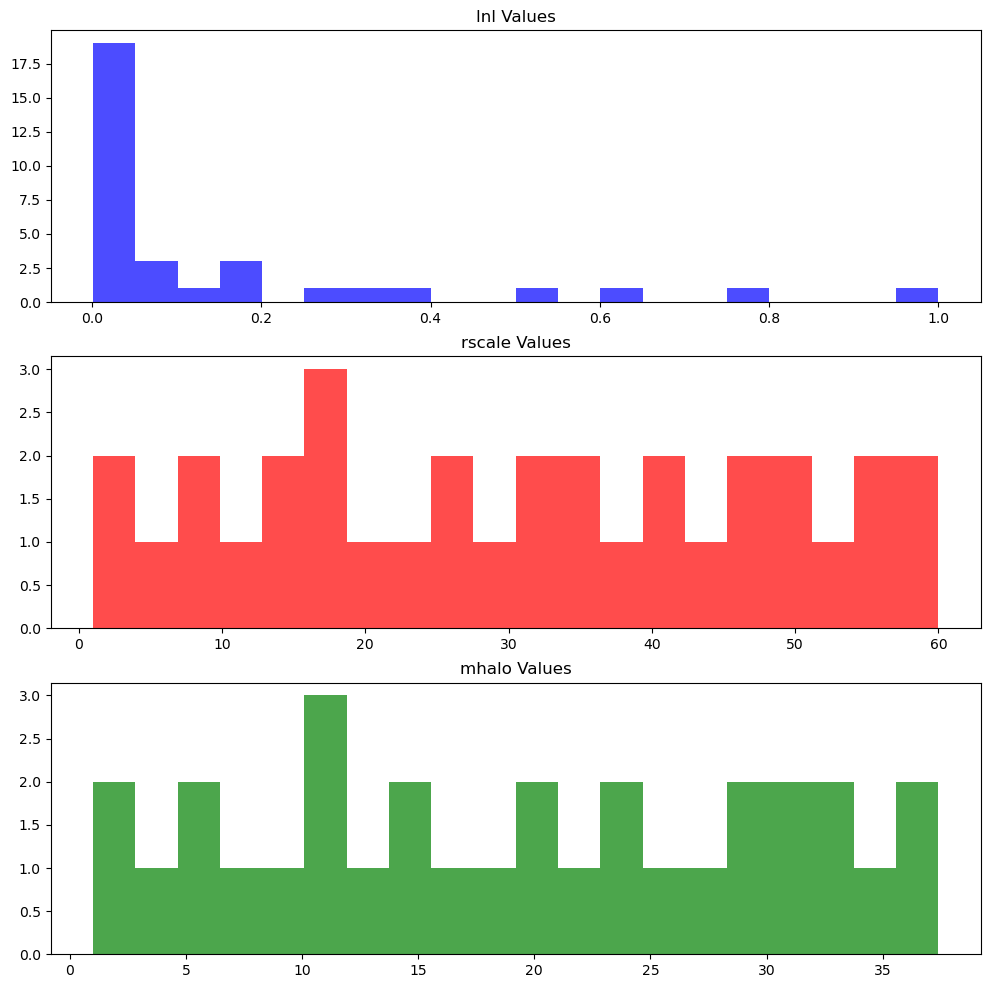

In [ ]:
if buildEnv:
    # Those number DO NOT look right, let's check the input values and see if they are correct
    lnl_values = log_df['lnl'].unique()
    rscale_values = log_df['rscale'].unique()
    mhalo_values = log_df['mhalo'].unique()

    # Create 3 subplots for each and do a histogram
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    bins = 20

    axs[0].hist( lnl_values, bins=bins, color='b', alpha=0.7 )
    axs[0].set_title("lnl Values")

    axs[1].hist( rscale_values, bins=bins, color='r', alpha=0.7 )
    axs[1].set_title("rscale Values")

    axs[2].hist( mhalo_values, bins=bins, color='g', alpha=0.7 )
    axs[2].set_title("mhalo Values")


    # So there is a good spread of the input values... but why are the orbit_n only 3 different values?

In [ ]:
# There are too many orbits to load in at the same time.  Let's just load them when we need them later. 
if buildEnv and False:
    import time

    # Load Pts
    start = time.time()
    c = 0
    n = log_df.shape[0]
    # n = 1000

    spam_orbits = {}

    for idx, row in log_df.iterrows():
        loc1 = row['orbit_loc_1']
        loc2 = row['orbit_loc_2']

        spam_orbits[idx] = {}
        spam_orbits[idx][0] = np.load( loc1 )['arr_0']
        spam_orbits[idx][1] = np.load( loc2 )['arr_0']

        # Print shape
        # print( f"Loaded Orbit: {idx} - Shape: {spam_orbits[idx].shape}" )

        if c >= n:
            break
        c +=1 

        print( f"Loaded {c} / {n} orbits", end='\r')

    end = time.time()

    print( f"Time to load {n} sets of points: {end-start} seconds" )

In [ ]:

def compute_weighted_error( path_tng, spam_orbit, dev_print = False):
    """
    Computes the weighted error between the true path and the simulated path.

    Parameters:
    - path_tng: (dictionary) contains the true path, spline function, and weight function for the tng orbit.
    - spam_orbit: (numpy array Nx7), spam simulated path.

    
    Returns:
    - E: float, total weighted error.
    """

    # length and times of spam orbit
    n_spam = len(spam_orbit)
    times = spam_orbit[:,-1]
    dt = abs((times[-1] - times[0]) / (n_spam - 1))

    # If length of times is under n_min, find dt and extrapolate t to n_min
    if len(times) < n_min:

        # Calc how many more steps we need to take to reach n_min
        n_more = n_min - len(times)

        # Extratolape new times  before the orbit starts
        new_times = np.linspace( times[0]-n_more*dt, times[0]-dt, n_more)
        added_times = np.concatenate( (new_times, times, ) )

        if dev_print:
            print( f"Times: {times.shape}")
            print( f"New Times: {new_times.shape}")
            print(f"Added Times: {added_times.shape}")
            #print first 10 values each
            print( times[:10])
            print( added_times[:10])

            # Print last 10 values
            print( times[-10:])
            print( added_times[-10:])
        
        times = added_times
    
    else:
        n_more = 0

    # Create new tng_path from spline func using spam times
    tng_orbit = np.array([ [spline(t) for spline in path_tng['s_fixed_su_cubic_nat_func']] for t in times ])
    n_tng = len(tng_orbit)

    if dev_print: print( f"Path TNG: {tng_orbit.shape}")

    # Initialize errors and weights
    errors = np.zeros(n_tng)
    weights = np.zeros(n_tng)

    # Compute errors
    for i in range(n_tng):
        if i < n_more:
            # Directly compare positions for same time step
            e = np.linalg.norm(spam_orbit[0,0:3] - tng_orbit[i,0:3]) ** 2
        else:
            # Use first simulated position
            spam_idx = i - n_more
            e = np.linalg.norm(spam_orbit[spam_idx,0:3] - tng_orbit[i,0:3]) ** 2
        errors[i] = e

    if dev_print: print( f"Errors: {errors.shape}")

    # Compute weights
    weights[:-n_min] = 1  # Full weight before minimum length
    weights[-n_min:] = np.linspace(1, 0, n_min)

    # Compute weighted error
    E = np.sum(weights * errors)
    total_weight = np.sum(weights)
    E_normalized = E / total_weight

    return E_normalized

class score_wrapper_class:

    def __init__( self, pid, ):
        self.pid = pid
        self.t_row, self.t_df, self.t_ar, self.path = get_tng_target_orbit( self.pid )

    def score_wrapper( self, spam_orbit ):
        return compute_weighted_error( self.path, spam_orbit )


if buildEnv:

    # Get idx of orbit with shortest length
    idx = np.argmin([ len(spam_orbits[i]) for i in spam_orbits.keys() ])

    # get idx of longest orbit
    idx_long = np.argmax([ len(spam_orbits[i]) for i in spam_orbits.keys() ])
    
    # Print index values and lengths they represent
    print(f"Shortest Orbit: {idx} - Length: {len(spam_orbits[idx])}")
    print(f"Longest Orbit: {idx_long} - Length: {len(spam_orbits[idx_long])}")
    
    hand_E = compute_weighted_error(path1, hand_spam_orbit, dev_print=False )
    short_E = compute_weighted_error(path1, spam_orbits[idx], dev_print=True)
    long_E = compute_weighted_error(path1, spam_orbits[idx_long], dev_print=False )

    print(f"Error")
    print(f"Best by Hand Error: {hand_E:.10f}")
    print(f"Longest Error: {long_E:.10f}")
    print(f"Shortest error: {short_E:.10f}")

    print("\nTesting wrapper class")
    score_class = score_wrapper_class( p1 )
    print( f"Best Hand Score: {score_class.score_wrapper( hand_spam_orbit )}")
    print( f"Longest Score: {score_class.score_wrapper( spam_orbits[idx_long] )}")
    print( f"Shortest Score: {score_class.score_wrapper( spam_orbits[idx] )}")

    

Shortest Orbit: 206 - Length: 290
Longest Orbit: 95 - Length: 10966
Times: (290,)
New Times: (710,)
Added Times: (1000,)
[89.4  89.4  89.41 89.41 89.41 89.41 89.41 89.41 89.41 89.41]
[88.69 88.69 88.7  88.7  88.7  88.7  88.7  88.7  88.7  88.7 ]
[89.68 89.68 89.69 89.69 89.69 89.69 89.69 89.69 89.69 89.69]
[89.68 89.68 89.69 89.69 89.69 89.69 89.69 89.69 89.69 89.69]
Path TNG: (1000, 6)
Errors: (1000,)
Error
Best by Hand Error: 0.0508556885
Longest Error: 20.7491779138
Shortest error: 0.7507331409

Testing wrapper class
Best Hand Score: 0.05085568854949315
Longest Score: 20.7491779138017
Shortest Score: 0.7507331409059093


In [ ]:


if buildEnv:

    # Create a test input
    test_input = {
        'path_tng': path1,
        'spam_orbit': hand_spam_orbit,
    }

    # Run the error wrapper
    test_error = error_wrapper( test_input )
    print( f"Test Error: {test_error}" )

NameError: name 'hand_spam_orbit' is not defined

In [ ]:
if buildEnv:
    # Let's iterate over the spam_orbits and compute the error
    n = len( spam_orbits )
    for i in spam_orbits.keys():
        print( i, n, end='\r')
        E = compute_weighted_error(path1, spam_orbits[i], dev_print=False )
        log_df.loc[i, 'error'] = E

    print( log_df.head() )



        lnl     rscale      mhalo            p_id  \
0  0.100000  10.000000  20.000000  62000000190717   
1  0.001000   1.000000   2.514867  62000000190717   
2  0.031623   2.783158   2.514867  62000000190717   
3  0.001000   7.745967  15.905415  62000000190717   
4  0.031623   7.745967  40.000000  62000000190717   

                                           orbit_loc  orbit_n  c     error  
0  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     5086  0  9.636565  
1  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     2434  1  2.435074  
2  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     1515  2  0.869007  
3  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     5002  3  6.946709  
4  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     5002  4  8.701170  


In [ ]:
if buildEnv:

    # save log 
    log_df.to_csv( 'test_log_df.csv', index=False )

In [ ]:
if buildEnv:
    log_df = pd.read_csv( 'test_log_df.csv' )
    print( log_df.head() )

        lnl     rscale      mhalo            p_id  \
0  0.100000  10.000000  20.000000  62000000190717   
1  0.001000   1.000000   2.514867  62000000190717   
2  0.031623   2.783158   2.514867  62000000190717   
3  0.001000   7.745967  15.905415  62000000190717   
4  0.031623   7.745967  40.000000  62000000190717   

                                           orbit_loc  orbit_n  c     error  
0  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     5086  0  9.636565  
1  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     2434  1  2.435074  
2  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     1515  2  0.869007  
3  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     5002  3  6.946709  
4  /home/mbo2d/galStuff/data/orbit_gridsearch/620...     5002  4  8.701170  


In [ ]:
def interactive_3d_scatter_heat_plot( in_inputs, in_scores, title = '3D Heat Map of Input Scores',\
                                      log_values = [False, False, False, False],   #  [x, y, z, score]
                                    ):


    # Copy inputs and scores
    inputs = np.copy( in_inputs )
    scores = np.copy( in_scores )

    # Normalize scores for visualization
    normalized_scores = (scores - scores.min()) / (scores.max() - scores.min())

    # If any log_values are true, apply log scaling.  Keep true values for axis plot
    for i, scale in enumerate(log_values):

        if scale:
            if i == 3:
                scores = np.log1p(scores)
            else:
                inputs[:,i] = np.log1p(inputs[:,i])



    # Create a 3D scatter plot
    fig = px.scatter_3d(
        x=inputs[:, 0], 
        y=inputs[:, 1], 
        z=inputs[:, 2],
        color=normalized_scores,  # Heat map based on scores
        size=1/(scores + 1e-6),   # Larger size for smaller scores
        color_continuous_scale='Turbo',  # Rainbow-like color scale
        title="3D Heat Map of Input Scores"
    )
    

    # Adjust layout
    fig.update_layout(
        scene=dict(
            xaxis_title="Input 1",
            yaxis_title="Input 2",
            zaxis_title="Input 3"
        )
    )

    # Show the interactive plot
    fig.show()


if buildEnv:

    inputs = log_df[['lnl', 'rscale', 'mhalo']].values
    scores = log_df['error'].values

    # Visualize the input points and scores
    interactive_3d_scatter_heat_plot(inputs, scores, log_values=[False, True, True, True])


# Run Gridsearch cmds above via cluster, review results

In [ ]:
def get_top_results( t_id, n_results = 5, dev_print = False ):
        
        output = '/home/mbo2d/galStuff/data/orbit_gridsearch/%s_2.csv' % t_id
        grid_search_df = pd.read_csv(output)

        # rename rscale to r_scale
        grid_search_df = grid_search_df.rename(columns={'rscale': 'r_scale'})

        # Filter out rows that resulted in short paths
        grid_search_df = grid_search_df[ grid_search_df['lnl'] <= 0.1 ]
        grid_search_df = grid_search_df[ grid_search_df['mhalo'] != 1.0 ]

        if dev_print:
            print( f"Results: {grid_search_df.shape}" )
            print( f"Best Score:", grid_search_df['final_value'].min() )
            print( grid_search_df.head() )
            

        # Grab the lowest n_results final_value rows
        top_results = grid_search_df.nsmallest(n_results, 'final_value')

        return top_results
    

if buildEnv and False:
    
        # Get grid_search results
        t_id = 62000000190717

        top_results = get_top_results( t_id, 3, True )

        # Print quantity of unique final values
        print("\nTOP RESULTS")
        print( top_results )

        in_var = []
        in_var.append({ 'label':"SPAM Default" })

        in_var.append( {
                'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
                'label': 'Discovered by Hand', 
        })

        c = 0
        for idx, row in top_results.iterrows():
            in_var.append( {
                'lnl': row['lnl'], 'r_scale': row['r_scale'], 'mhalo': row['mhalo'],
                'label': f'Top Grid Result: {c}', 'score': row['final_value']
            })
            c += 1

        plot_tng_spam_orbits( t_row, t_df, pts_raw, in_var, True, title = 'Top Orbit Gridsearch Results' )
                
        # End the MPI process

In [ ]:
if buildEnv:
    # Sort log_df by error
    log_df = log_df.sort_values(by='error', ascending=True)
    
    # Get first 20
    top_results = log_df.head(20)
    print( top_results )

       lnl     rscale  mhalo            p_id  \
682   0.01  15.326189    1.0  62000000190717   
2599  0.01   1.726183    1.0  62000000190717   
1018  0.01  20.136203    1.0  62000000190717   
2035  0.01   5.143521    1.0  62000000190717   
3272  0.01   8.878658    1.0  62000000190717   
2373  0.01   3.914868    1.0  62000000190717   
2714  0.01  34.758771    1.0  62000000190717   
904   0.01   1.000000    1.0  62000000190717   
3384  0.01  26.455806    1.0  62000000190717   
1131  0.01  60.000000    1.0  62000000190717   
1584  0.01  45.667563    1.0  62000000190717   
2486  0.01   1.313843    1.0  62000000190717   
118   0.01   2.979708    1.0  62000000190717   
1922  0.01   2.267933    1.0  62000000190717   
2826  0.01  11.665161    1.0  62000000190717   
569   0.01   6.757778    1.0  62000000190717   
3277  1.00   1.726183    1.0  62000000190717   
574   1.00   2.267933    1.0  62000000190717   
1136  1.00  26.455806    1.0  62000000190717   
1916  1.00  60.000000    1.0  6200000019

In [ ]:
def plot_tng_spam_pts( t_row, t_df, pts_raw, spam_var, dev_print = False, title = 'TNG SPAM Comparison', n_spam_pts = 2000 ):

    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )

    # Extract path
    p_path, s_path = get_moving_path( t_row, t_df )

    # Save in convenient format
    path = {}
    path['p_moving'] = p_path
    path['s_moving'] = s_path
    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
    pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
    pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']
    
    # convert tng pts to spam units
    pts_su = np.copy( pts_tu )
    pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
    pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

    # Convert the paths to SPAM units
    path['times_su'] = convert_time_tng_to_spam( path['times'] )
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    
    # Create Splines for plotting
    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])

    # Add plots and labels
    plot_list = [path['s_fixed_su_cubic_herm_test']]
    plot_labels = ['Hermite', ]

    # Create list of tuples from secondary fixed path and snap data
    annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]
    annotate_data.append( ([0,0], 'Primary') ) # primary galaxy center

    # Create SPAM orbits

    # Get lnl, r_scale, mhalo as dict
    x_set = { k: spam_var[k] for k in ['lnl', 'r_scale', 'mhalo'] }

    if dev_print:
        print(f"Running SPAM Simulation with: {x_set}")

    
    # Use input to prep SPAM simulation
    sim.set_simulation_variables( **x_set )

    r_scale = 2
    spam_ar[8:9] = r_scale  * spam_ar[8:9]

    # Run SPAM simulation
    spam_orbit = spam_orbit_wrapper_squared( spam_ar, current_time=t_row['times_su'], dev_print=dev_print )


    if dev_print:
        print( f"SPAM Orbit Shape: {spam_orbit.shape}" )
    
    if score is not None:
        score2 = score_run_v1( spam_orbit, path['s_fixed_su_cubic_herm_func'], dev_print=False )

        print(f"Score: {score} - {score2}")
    
    # Now run 
    ipts, fpts = sim.basic_run_wrapper( spam_ar, npts1 = n_spam_pts, npts2 = n_spam_pts, heat1 = 0.1, heat2 = 0.1,)
    
    # append to plot lists
    plot_list.append( spam_orbit )
    plot_labels.append( 'SPAM_run' )
    annotate_data = add_annotate_times( annotate_data, spam_orbit, path['times_su'] )

    # Create a side by side subplot of size 12x12
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))

    # set overall title
    fig.suptitle(title, fontsize=16)

    # tighter layout
    plt.tight_layout()

    xy_histogram( \
        pts_su, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 3,
        annotate_data= annotate_data,
        title = 'TNG Pts',
        ext_ax = axs[0],
        bins = 200,
    )

    xy_histogram( \
        fpts, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 3,
        annotate_data= annotate_data,
        title = 'SPAM Pts',
        ext_ax = axs[1],
        bins = 200
    )

    plt.show()

if buildEnv and True:

    # x_set = {
    #     'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
    #     'label': 'Top_Grid_Result_0'
    # }

    plot_tng_spam_pts( t_row, t_df, pts_raw, top_grid_result.iloc[0], True )

NameError: name 'top_grid_result' is not defined

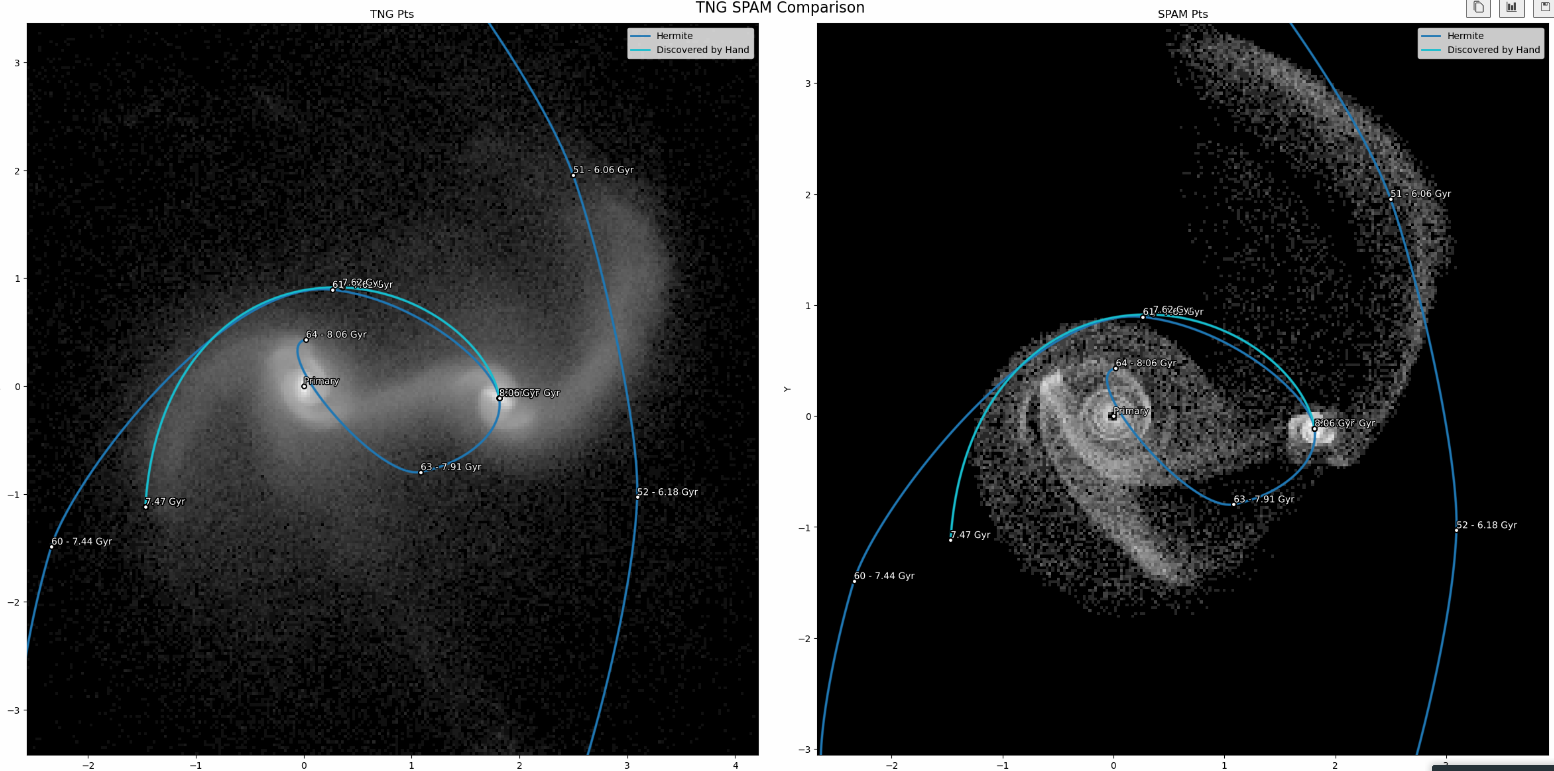

In [ ]:

if buildEnv and True:

    # print( good_targets.head )
    # plot_tng_spam_pts( t_row, t_df, pts_raw, top_grid_result, True )

    c = 0
    for i, row in good_targets.iterrows():


        tmp_id = row['p_SubhaloIDRaw']


        print( c, i, tmp_id )

        #$ Verify particles are in the right place
        try:
            tmp_pts = load_pts_data( tmp_id, dev_print = False )
        except:
            print( f"Error: {tmp_id}" )
            continue

        top_result = get_top_results( row['p_SubhaloIDRaw'], 1, True )

        tmp_row, tmp_df = extractTargetData( tmp_id, tng_targets, dev_print = False )        

        plot_tng_spam_pts( tmp_row, tmp_df, tmp_pts, top_result.iloc[0], True )

        c +=1 
        if c > 10: break

0 496 75000000317209


NameError: name 'get_top_results' is not defined